# Prospective Memory DDPM Analysis

This notebook implements a standalone, reproducible pipeline for analyzing prospective memory representations in a DDPM model. Each section is clearly separated and documented for legibility and ease of use.

**Outline:**
1. Setup: environment, imports, constants
2. Sample data: generate or load minimal dataset
3. Core functions: main logic and helpers
4. Main execution cell: script-style entry point
5. Argument parsing: CLI with argparse
6. Unit tests: pytest/unittest
7. Logging & error handling
8. Quick demos / example runs
9. Visualization: plot outputs
10. Save & export: write outputs
11. Performance: profiling and optimization


## 1. Setup: Environment, Imports, Constants

Install and import required libraries. Define constants and configuration variables for the analysis.

In [52]:
# Install required packages if missing (uncomment if needed)
# !pip install numpy matplotlib scikit-learn pandas pytest

import os
import sys
import logging
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from pathlib import Path
import colorsys
import pickle
import json
import torch
from purias_utils.multiitem_working_memory.util.circle_utils import polar2cart

# Get absolute paths
REPO_ROOT = Path('/scratch3/shaiq_home/repos/behaviour_ddpm')
DATA_DIR = REPO_ROOT / 'ddpm' / 'analysis' / 'new_analysis'

# Model and analysis parameters
PREP_IDX = 2  # Start of delay 1
NEURAL_DIM = 16  # Dimensionality of extracted neural state
N_TRIALS = 200  # Number of non-swap trials to generate
ANGLE_STEP = 30  # Angle step in degrees
SEED = 42
np.random.seed(SEED)

# Print to verify paths
print(f"Working directory: {os.getcwd()}")
print(f"Data directory: {DATA_DIR}")


Working directory: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis
Data directory: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis


In [ ]:
# Section 2 - Model Loading and Configuration

import torch
import yaml

# Add DDPM modules to path
sys.path.insert(0, str(REPO_ROOT))

from ddpm.utils.loading import generate_model_and_task_from_args_path_multiepoch
from purias_utils.util.arguments_yaml import ConfigNamepace

# Model configuration paths
ARGS_PATH = REPO_ROOT / "results_link_sampler/index_cued_first_diffusion_0.3_swap_recovery_1/args.yaml"
CHECKPOINT_PATH = REPO_ROOT / "results_link_sampler/index_cued_first_diffusion_0.3_swap_recovery_1/state.mdl"

print(f"Loading model from: {ARGS_PATH}")
print(f"Loading checkpoint from: {CHECKPOINT_PATH}")

# Create model-specific results directory
model_name = CHECKPOINT_PATH.parent.name
RESULTS_DIR = DATA_DIR / 'results' / model_name
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results directory: {RESULTS_DIR}")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load model and task
args, task, model, mse_key_pred, mse_key_target = generate_model_and_task_from_args_path_multiepoch(
    str(ARGS_PATH), device
)
print("Model and task loaded successfully")

# Load checkpoint
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
model.load_state_dict(checkpoint)
print("✓ Checkpoint loaded successfully")

model.eval()
print("Model ready for inference")

# Store angle step from config
ANGLE_STEP = 30


Loading model from: /scratch3/shaiq_home/repos/behaviour_ddpm/results_link_sampler/index_cued_first_diffusion_0.3_swap_7/args.yaml
Loading checkpoint from: /scratch3/shaiq_home/repos/behaviour_ddpm/results_link_sampler/index_cued_first_diffusion_0.3_swap_7/state.mdl
Results directory: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_7
Using device: cuda
Model and task loaded successfully
✓ Checkpoint loaded successfully
Model ready for inference


In [54]:
# Cell: Section 3 - Trial Generation
"""
## 3. Generate Trial Combinations (Non-Swap Trials)

Generate all combinations of cue, color1, and color2 for analysis.
"""

def generate_trial_combinations(angle_step=30):
    """
    Generate all non-swap trial combinations.
    
    Args:
        angle_step: Step size for color angles in degrees
        
    Returns:
        List of trial dictionaries with cue, color1_angle, color2_angle
    """
    angles = list(range(0, 360, angle_step))
    trials = []
    
    for cue in [1, 2]:
        for color1 in angles:
            for color2 in angles:
                trials.append({
                    'cue': cue,
                    'color1_angle': color1,
                    'color2_angle': color2,
                    'swap': False
                })
    return trials

trials = generate_trial_combinations()

In [55]:
# Section 4 - Neural State Extraction

def extract_neural_state_from_model(trial, task, model, device, prep_idx=2):
    """
    Extract 16D neural state for a single trial at specified timepoint.
    
    Args:
        trial: Dictionary with cue, color1_angle, color2_angle
        task: Task object for generating trial information
        model: Trained DDPM model
        device: torch device
        prep_idx: Prep epoch index to extract (default=2 for delay 1)
        
    Returns:
        16D neural state
    """
    with torch.no_grad():
        # Convert angles (degrees) to radians for probe and report features
        # Keep on CPU because task.sample_gen.linking_matrix is numpy
        probe_features = torch.tensor([[trial['color1_angle'], trial['color2_angle']]]) * (np.pi / 180)
        report_features = torch.tensor([[trial['color1_angle'], trial['color2_angle']]]) * (np.pi / 180)
        
        # Create override dict with stimulus features  
        override_stimulus_features = {
            'probe_features': probe_features,
            'report_features': report_features,
        }
        override_stimulus_cart_features = {}
        for k in override_stimulus_features.keys():
            override_stimulus_cart_features[f'{k}_cart'] = torch.stack(polar2cart(1.0, override_stimulus_features[k]), -1)
        
        # Keep everything on CPU for trial generation
        override_stimulus_features_dict = {}
        for k, v in override_stimulus_features.items():
            override_stimulus_features_dict[k] = v
        for k, v in override_stimulus_cart_features.items():
            override_stimulus_features_dict[k] = v
        
        # Add cued_item_idx (also on CPU)
        override_stimulus_features_dict['cued_item_idx'] = torch.tensor([trial['cue'] - 1])  # Convert to 0-indexed
        
        # Generate variable dict from task variable generator
        task_variable_dict = task.task_variable_gen.generate_variable_dict(
            batch_size=1,
            override_stimulus_features_dict=override_stimulus_features_dict
        )
        
        # Generate trial information using the task with override
        trial_info = task.generate_trial_information(
            batch_size=1,
            num_samples=1,
            override_task_variable_information=task_variable_dict
        )
        
        # Now move trial info to device for model inference
        prep_network_inputs_device = []
        for inp in trial_info.prep_network_inputs:
            if isinstance(inp, torch.Tensor):
                prep_network_inputs_device.append(inp.to(device))
            else:
                prep_network_inputs_device.append(inp)
        
        diffusion_network_inputs_device = []
        for inp in trial_info.diffusion_network_inputs:
            if isinstance(inp, torch.Tensor):
                diffusion_network_inputs_device.append(inp.to(device))
            else:
                diffusion_network_inputs_device.append(inp)
        
        # Run model to get preparatory states
        prep_dicts, samples_dict = model.generate_samples(
            prep_network_inputs=prep_network_inputs_device,
            diffusion_network_inputs=diffusion_network_inputs_device,
            prep_epoch_durations=trial_info.prep_epoch_durations,
            diffusion_epoch_durations=trial_info.diffusion_epoch_durations,
            samples_shape=[1, 1],
            noise_scaler=1.0,
        )
        
        # Extract neural state from the specified prep epoch
        if prep_idx >= len(prep_dicts):
            raise ValueError(f"prep_idx {prep_idx} exceeds number of prep epochs {len(prep_dicts)}")
        
        # Get the postprep state from the specified epoch
        # This is the neural state at the start of the next epoch (delay 1 for prep_idx=2)
        neural_state = prep_dicts[prep_idx]['postprep_state'][0, 0, :16].cpu().numpy()
        
        return neural_state

# Extract neural states for all trials
print(f"Extracting neural states at prep_idx={PREP_IDX}...")
print(f"Total trials to process: {len(trials)}")
neural_states = []
metadata = []

for i, trial in enumerate(trials):
    if i % 50 == 0:
        print(f"  Processing trial {i}/{len(trials)}")
    try:
        state = extract_neural_state_from_model(trial, task, model, device, prep_idx=PREP_IDX)
        neural_states.append(state)
        metadata.append([trial['cue'], trial['color1_angle'], trial['color2_angle']])
    except Exception as e:
        print(f"  Trial {i} failed: {e}")
        import traceback
        traceback.print_exc()
        break  # Stop on first error to debug

neural_states = np.array(neural_states)
metadata = np.array(metadata)

print(f"\n✓ Extracted {len(neural_states)} neural states")
print(f"  Shape: {neural_states.shape}")
if len(neural_states) > 0:
    print(f"  Mean: {neural_states.mean():.4f}, Std: {neural_states.std():.4f}")

Extracting neural states at prep_idx=2...
Total trials to process: 288
  Processing trial 0/288
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING


USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PREC

In [56]:
# Cell: Section 5 - Separate by Cue and Average
"""
## 5. Separate by Cue and Average at Delay 1 Onset

Group trials by cue and compute average neural states.
"""

# Separate by cue
cue1_mask = metadata[:, 0] == 1
cue2_mask = metadata[:, 0] == 2

cue1_states = neural_states[cue1_mask]
cue2_states = neural_states[cue2_mask]
cue1_metadata = metadata[cue1_mask]
cue2_metadata = metadata[cue2_mask]

print(f"Cue 1 trials: {len(cue1_states)}")
print(f"Cue 2 trials: {len(cue2_states)}")

# Compute average states per cue
cue1_mean = cue1_states.mean(axis=0)
cue2_mean = cue2_states.mean(axis=0)

print(f"\nCue 1 mean state: {cue1_mean[:5]}... (first 5 dims)")
print(f"Cue 2 mean state: {cue2_mean[:5]}... (first 5 dims)")
print(f"\nDifference between cues:")
print(f"  Max abs diff: {np.abs(cue1_mean - cue2_mean).max():.6f}")
print(f"  Mean abs diff: {np.abs(cue1_mean - cue2_mean).mean():.6f}")
print(f"  L2 distance: {np.linalg.norm(cue1_mean - cue2_mean):.6f}")

Cue 1 trials: 144
Cue 2 trials: 144

Cue 1 mean state: [123.78696    68.243576   43.004692  126.90091    14.1275215]... (first 5 dims)
Cue 2 mean state: [125.051445  67.6037    40.583084 126.81845   12.851173]... (first 5 dims)

Difference between cues:
  Max abs diff: 6.462044
  Mean abs diff: 1.751041
  L2 distance: 9.411934


In [57]:
# Cell: Section 6 - Bin by Cued Color Index
"""
## 6. Bin Trials by Cued Color Index

Bin trials according to the cued color angle (color1 for cue 1, color2 for cue 2).
"""

def bin_angle(angle, bin_size=30.0):
    """Bin an angle into discrete bins."""
    return int(angle // bin_size) % int(360 // bin_size)

def bin_and_average_by_cued_color(states, metadata, n_bins=12):
    """
    Bin trials by cued color and average neural states.
    
    Args:
        states: Neural states array [n_trials, 16]
        metadata: Metadata array [n_trials, 3] with [cue, color1, color2]
        n_bins: Number of angular bins (default 12 for 30° bins)
        
    Returns:
        Dictionary with binned and averaged states per cue
    """
    bin_size = 360.0 / n_bins
    
    # Initialize storage
    binned_data = {
        1: {b: [] for b in range(n_bins)},
        2: {b: [] for b in range(n_bins)}
    }
    
    # Bin trials
    for i, (cue, c1, c2) in enumerate(metadata):
        cue = int(cue)
        cued_angle = c1 if cue == 1 else c2
        bin_idx = bin_angle(cued_angle, bin_size)
        binned_data[cue][bin_idx].append(states[i])
    
    # Average per bin
    averaged_data = {
        1: np.zeros((n_bins, states.shape[1])),
        2: np.zeros((n_bins, states.shape[1]))
    }
    
    for cue in [1, 2]:
        for b in range(n_bins):
            if len(binned_data[cue][b]) > 0:
                averaged_data[cue][b] = np.mean(binned_data[cue][b], axis=0)
            else:
                averaged_data[cue][b] = np.nan
    
    return averaged_data, binned_data

# Bin and average
N_BINS = 12
averaged_states, binned_trials = bin_and_average_by_cued_color(neural_states, metadata, N_BINS)

print(f"Binned trials into {N_BINS} angular bins (30° each)")
print(f"\nTrials per bin:")
for cue in [1, 2]:
    counts = [len(binned_trials[cue][b]) for b in range(N_BINS)]
    print(f"  Cue {cue}: {counts}")
    print(f"    Total: {sum(counts)}, Mean: {np.mean(counts):.1f}")

print(f"\nAveraged states shape per cue: {averaged_states[1].shape}")

Binned trials into 12 angular bins (30° each)

Trials per bin:
  Cue 1: [12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12]
    Total: 144, Mean: 12.0
  Cue 2: [12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12]
    Total: 144, Mean: 12.0

Averaged states shape per cue: (12, 16)


In [58]:
# Cell: Section 7 - PCA on Binned States
"""
## 7. Perform PCA on Binned Average States

Apply PCA to the binned and averaged neural states for dimensionality reduction.
"""

# Combine all binned states for PCA
all_binned_states = np.vstack([averaged_states[1], averaged_states[2]])

# Remove any NaN rows
valid_mask = ~np.isnan(all_binned_states).any(axis=1)
all_binned_states_clean = all_binned_states[valid_mask]

print(f"All binned states shape: {all_binned_states.shape}")
print(f"Valid states for PCA: {all_binned_states_clean.shape}")

# Perform PCA
pca = PCA(n_components=min(3, all_binned_states_clean.shape[0]-1))
pca_coords = pca.fit_transform(all_binned_states_clean)

print(f"\nPCA results:")
print(f"  Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"  Cumulative variance: {pca.explained_variance_ratio_.cumsum()}")
print(f"  PCA coordinates shape: {pca_coords.shape}")

# Split back into cue groups
n_bins_cue1 = N_BINS
cue1_pca = pca_coords[:n_bins_cue1]
cue2_pca = pca_coords[n_bins_cue1:n_bins_cue1*2]

print(f"\nCue 1 PCA shape: {cue1_pca.shape}")
print(f"Cue 2 PCA shape: {cue2_pca.shape}")

# Compute separation
cue1_center = cue1_pca.mean(axis=0)
cue2_center = cue2_pca.mean(axis=0)
separation = np.linalg.norm(cue1_center - cue2_center)

print(f"\nCue separation in PCA space: {separation:.4f}")

All binned states shape: (24, 16)
Valid states for PCA: (24, 16)

PCA results:
  Explained variance ratio: [0.52494102 0.38859686 0.04321671]
  Cumulative variance: [0.52494102 0.91353788 0.95675459]
  PCA coordinates shape: (24, 3)

Cue 1 PCA shape: (12, 3)
Cue 2 PCA shape: (12, 3)

Cue separation in PCA space: 2.3543


## 2D Binning by Target AND Distractor Colors

Now we'll bin the data by **both** the target color and the distractor color at `prep_idx=2`, creating a 2D representation (12×12=144 bins per cue) to see if both colors are represented in the neural state space.

In [59]:
# Extract states at prep_idx=2 and bin by BOTH target and distractor
print("="*60)
print("BINNING BY TARGET AND DISTRACTOR AT prep_idx=2")
print("="*60)

# First, extract states at prep_idx=2 if PREP_IDX is not already 2
if PREP_IDX != 2:
    print(f"\nExtracting additional states at prep_idx=2 (currently using prep_idx={PREP_IDX})...")
    states_prep2 = []
    metadata_prep2 = []
    
    for i, trial in enumerate(trials):
        if i % 100 == 0 and i > 0:
            print(f"  Processing trial {i}/{len(trials)}")
        try:
            state = extract_neural_state_from_model(trial, task, model, device, prep_idx=2)
            states_prep2.append(state)
            metadata_prep2.append([trial['cue'], trial['color1_angle'], trial['color2_angle']])
        except Exception as e:
            print(f"  Trial {i} failed: {e}")
            break
    
    states_prep2 = np.array(states_prep2)
    metadata_prep2 = np.array(metadata_prep2)
    print(f"✓ Extracted {len(states_prep2)} states at prep_idx=2")
else:
    # Use the already extracted states
    print(f"\nUsing already extracted states at prep_idx={PREP_IDX}")
    states_prep2 = neural_states.copy()
    metadata_prep2 = metadata.copy()

print(f"\nTotal states at prep_idx=2: {len(states_prep2)}")
print(f"Shape: {states_prep2.shape}")

# Create bins for both target and distractor
# For cue=1: target=color1, distractor=color2
# For cue=2: target=color2, distractor=color1

def bin_by_target_and_distractor(states, metadata, n_bins=12):
    """
    Bin trials by both target color and distractor color.
    
    Args:
        states: Neural states array [n_trials, 16]
        metadata: Metadata array [n_trials, 3] with [cue, color1, color2]
        n_bins: Number of angular bins per dimension
        
    Returns:
        Dictionary with binned states per cue
    """
    bin_size = 360.0 / n_bins
    
    # Initialize storage: cue -> (target_bin, distractor_bin) -> [states]
    binned_data = {
        1: {},
        2: {}
    }
    
    # Bin trials
    for i, (cue, c1, c2) in enumerate(metadata):
        cue = int(cue)
        
        # Determine target and distractor based on cue
        if cue == 1:
            target_angle = c1
            distractor_angle = c2
        else:
            target_angle = c2
            distractor_angle = c1
        
        target_bin = bin_angle(target_angle, bin_size)
        distractor_bin = bin_angle(distractor_angle, bin_size)
        
        key = (target_bin, distractor_bin)
        if key not in binned_data[cue]:
            binned_data[cue][key] = []
        binned_data[cue][key].append(states[i])
    
    # Average per bin
    averaged_data = {1: {}, 2: {}}
    bin_counts = {1: {}, 2: {}}
    
    for cue in [1, 2]:
        for key, states_list in binned_data[cue].items():
            if len(states_list) > 0:
                averaged_data[cue][key] = np.mean(states_list, axis=0)
                bin_counts[cue][key] = len(states_list)
    
    return averaged_data, bin_counts

# Bin the data
averaged_2d, bin_counts_2d = bin_by_target_and_distractor(states_prep2, metadata_prep2, N_BINS)

print(f"\nBinned by target × distractor (12 × 12 = 144 bins per cue)")
print(f"Cue 1: {len(averaged_2d[1])} non-empty bins")
print(f"Cue 2: {len(averaged_2d[2])} non-empty bins")

# Show some statistics
for cue in [1, 2]:
    counts = list(bin_counts_2d[cue].values())
    print(f"\nCue {cue} bin occupancy:")
    print(f"  Total bins with data: {len(counts)}")
    print(f"  Trials per bin - mean: {np.mean(counts):.1f}, min: {min(counts)}, max: {max(counts)}")

BINNING BY TARGET AND DISTRACTOR AT prep_idx=2

Using already extracted states at prep_idx=2

Total states at prep_idx=2: 288
Shape: (288, 16)

Binned by target × distractor (12 × 12 = 144 bins per cue)
Cue 1: 144 non-empty bins
Cue 2: 144 non-empty bins

Cue 1 bin occupancy:
  Total bins with data: 144
  Trials per bin - mean: 1.0, min: 1, max: 1

Cue 2 bin occupancy:
  Total bins with data: 144
  Trials per bin - mean: 1.0, min: 1, max: 1


In [60]:
# PCA on 2D binned data
print("\n" + "="*60)
print("PCA ON 2D BINNED DATA")
print("="*60)

# Combine all 2D binned states for PCA
all_2d_states = []
all_2d_metadata = []  # Will store (cue, target_bin, distractor_bin)

for cue in [1, 2]:
    for (target_bin, distractor_bin), state in averaged_2d[cue].items():
        all_2d_states.append(state)
        all_2d_metadata.append((cue, target_bin, distractor_bin))

all_2d_states = np.array(all_2d_states)
all_2d_metadata = np.array(all_2d_metadata)

print(f"\nTotal 2D bins with data: {len(all_2d_states)}")
print(f"Shape: {all_2d_states.shape}")

# Check for NaNs
valid_mask = ~np.isnan(all_2d_states).any(axis=1)
all_2d_states_clean = all_2d_states[valid_mask]
all_2d_metadata_clean = all_2d_metadata[valid_mask]

print(f"Valid states for PCA: {len(all_2d_states_clean)}")

# Perform PCA
pca_2d = PCA(n_components=min(3, all_2d_states_clean.shape[0]-1))
pca_coords_2d = pca_2d.fit_transform(all_2d_states_clean)

print(f"\nPCA results:")
print(f"  Explained variance ratio: {pca_2d.explained_variance_ratio_}")
print(f"  Cumulative variance: {pca_2d.explained_variance_ratio_.cumsum()}")
print(f"  PCA coordinates shape: {pca_coords_2d.shape}")

# Split by cue
cue1_mask = all_2d_metadata_clean[:, 0] == 1
cue2_mask = all_2d_metadata_clean[:, 0] == 2

cue1_pca_2d = pca_coords_2d[cue1_mask]
cue1_meta_2d = all_2d_metadata_clean[cue1_mask]

cue2_pca_2d = pca_coords_2d[cue2_mask]
cue2_meta_2d = all_2d_metadata_clean[cue2_mask]

print(f"\nCue 1: {len(cue1_pca_2d)} bins")
print(f"Cue 2: {len(cue2_pca_2d)} bins")

# Compute separation
cue1_center_2d = cue1_pca_2d.mean(axis=0)
cue2_center_2d = cue2_pca_2d.mean(axis=0)
separation_2d = np.linalg.norm(cue1_center_2d - cue2_center_2d)

print(f"\nCue separation in 2D-binned PCA space: {separation_2d:.4f}")


PCA ON 2D BINNED DATA

Total 2D bins with data: 288
Shape: (288, 16)
Valid states for PCA: 288

PCA results:
  Explained variance ratio: [0.36189237 0.26030633 0.14527874]
  Cumulative variance: [0.36189237 0.6221987  0.76747745]
  PCA coordinates shape: (288, 3)

Cue 1: 144 bins
Cue 2: 144 bins

Cue separation in 2D-binned PCA space: 2.7741



VISUALISATION: TARGET vs DISTRACTOR ENCODING (COMBINED)

Creating separate averages for target and distractor (combining both cues)...
Target-only averaging (30° bins, both cues combined):
  Total target bins: 12
Distractor-only averaging (30° bins, both cues combined):
  Total distractor bins: 12

Combined states shape: (24, 16)
  12 target bins + 12 distractor bins

PCA on combined target+distractor:
  Explained variance: [0.5206994  0.39400485 0.04521232]
  Cumulative: [0.5206994  0.9147042  0.95991653]

Final PCA projections:
  Target: (12, 3)
  Distractor: (12, 3)


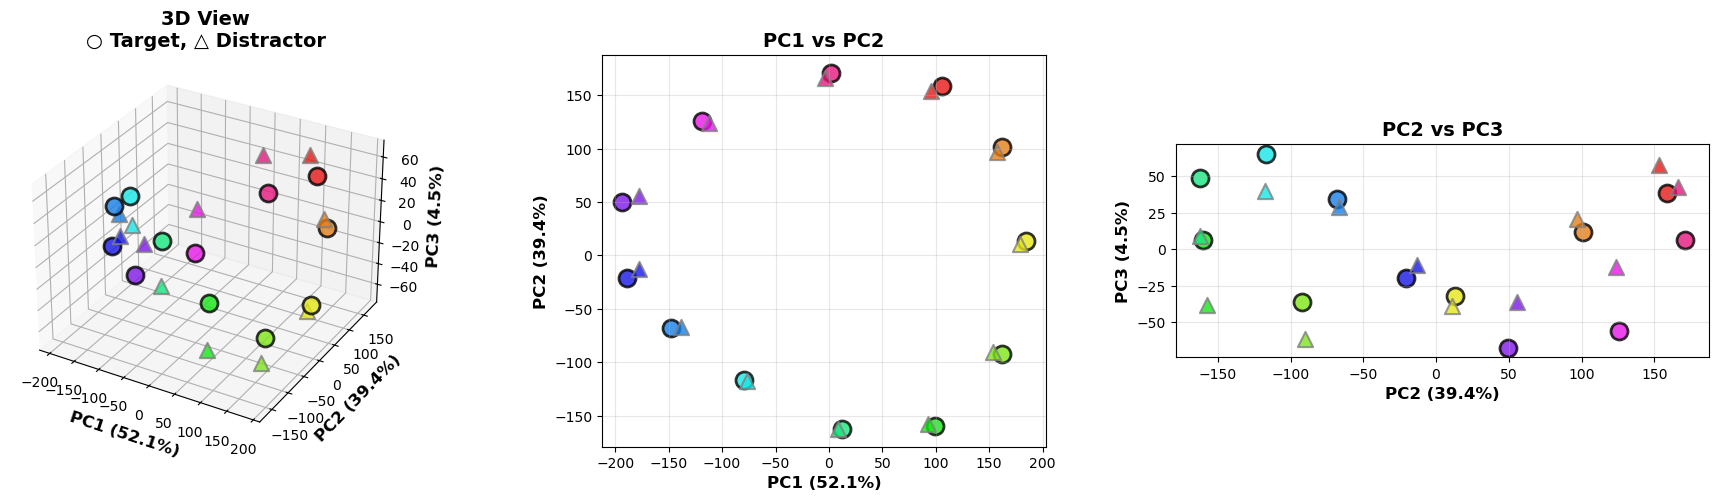


✓ Visualization saved to: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_7/2d_binning_target_vs_distractor_combined.png
   Layout: 1 row × 3 columns (3D, PC1-PC2, PC2-PC3)
   Using 12 colour bins (30° each)
   Large circles (○) = averaged by target colour (across all distractors and cues)
   Small triangles (△) = averaged by distractor colour (across all targets and cues)


In [61]:
# Visualisation of 2D binned data in PCA space
print("\n" + "="*60)
print("VISUALISATION: TARGET vs DISTRACTOR ENCODING (COMBINED)")
print("="*60)

# KEY INSIGHT: Combine both cues and create SEPARATE averages:
# 1. Average by TARGET only (collapsing across distractors AND cues) 
# 2. Average by DISTRACTOR only (collapsing across targets AND cues)
# Then run PCA on the combined set

# Use 12 bins (30° each) as in the original analysis
N_COLOR_BINS = 12  # 12 bins at 30° each

print("\nCreating separate averages for target and distractor (combining both cues)...")

# 1. Average by TARGET only (marginalizing over distractor and cue)
target_only_averaged = {}

for target_bin in range(N_BINS):
    # Collect all states with this target bin from BOTH cues
    states_for_target = []
    for cue in [1, 2]:
        for (fine_target, fine_distractor), state in averaged_2d[cue].items():
            if fine_target == target_bin:
                states_for_target.append(state)
    
    if len(states_for_target) > 0:
        target_only_averaged[target_bin] = np.mean(states_for_target, axis=0)

print(f"Target-only averaging (30° bins, both cues combined):")
print(f"  Total target bins: {len(target_only_averaged)}")

# 2. Average by DISTRACTOR only (marginalizing over target and cue)
distractor_only_averaged = {}

for distractor_bin in range(N_BINS):
    # Collect all states with this distractor bin from BOTH cues
    states_for_distractor = []
    for cue in [1, 2]:
        for (fine_target, fine_distractor), state in averaged_2d[cue].items():
            if fine_distractor == distractor_bin:
                states_for_distractor.append(state)
    
    if len(states_for_distractor) > 0:
        distractor_only_averaged[distractor_bin] = np.mean(states_for_distractor, axis=0)

print(f"Distractor-only averaging (30° bins, both cues combined):")
print(f"  Total distractor bins: {len(distractor_only_averaged)}")

# Combine target and distractor states for joint PCA
combined_states = []
combined_metadata = []  # (type, bin) where type: 0=target, 1=distractor

# Add target states
for target_bin, state in sorted(target_only_averaged.items()):
    combined_states.append(state)
    combined_metadata.append((0, target_bin))  # 0 = target

# Add distractor states
for distractor_bin, state in sorted(distractor_only_averaged.items()):
    combined_states.append(state)
    combined_metadata.append((1, distractor_bin))  # 1 = distractor

combined_states = np.array(combined_states)
combined_metadata = np.array(combined_metadata)

print(f"\nCombined states shape: {combined_states.shape}")
print(f"  {(combined_metadata[:, 0] == 0).sum()} target bins + {(combined_metadata[:, 0] == 1).sum()} distractor bins")

# Run PCA on combined set
pca_combined = PCA(n_components=3)
combined_pca = pca_combined.fit_transform(combined_states)

print(f"\nPCA on combined target+distractor:")
print(f"  Explained variance: {pca_combined.explained_variance_ratio_}")
print(f"  Cumulative: {pca_combined.explained_variance_ratio_.cumsum()}")

# Split back into target and distractor
target_mask = combined_metadata[:, 0] == 0
distractor_mask = combined_metadata[:, 0] == 1

target_pca_combined = combined_pca[target_mask]
target_bins_combined = combined_metadata[target_mask, 1].astype(int)

distractor_pca_combined = combined_pca[distractor_mask]
distractor_bins_combined = combined_metadata[distractor_mask, 1].astype(int)

print(f"\nFinal PCA projections:")
print(f"  Target: {target_pca_combined.shape}")
print(f"  Distractor: {distractor_pca_combined.shape}")

# Colour mapping (HSV for 12 bins)
def angle_to_colour(bin_idx, n_bins=12):
    """Convert angle bin (0-11) to HSV colour"""
    hue = bin_idx / n_bins
    return colorsys.hsv_to_rgb(hue, 0.9, 0.9)

# Create visualisation - 1 row × 3 columns format
fig = plt.figure(figsize=(18, 5))

target_pca_data = target_pca_combined
target_bins_data = target_bins_combined
distractor_pca_data = distractor_pca_combined
distractor_bins_data = distractor_bins_combined

# Plot 1: 3D view
ax = fig.add_subplot(131, projection='3d')

# Plot TARGET encoding (circles) with colors
for i in range(len(target_pca_data)):
    colour = angle_to_colour(target_bins_data[i], N_COLOR_BINS)
    ax.scatter(target_pca_data[i, 0], target_pca_data[i, 1], target_pca_data[i, 2],
              c=[colour], marker='o', s=150, alpha=0.8, 
              edgecolors='k', linewidth=2)

# Plot DISTRACTOR encoding (triangles) with colors
for i in range(len(distractor_pca_data)):
    colour = angle_to_colour(distractor_bins_data[i], N_COLOR_BINS)
    ax.scatter(distractor_pca_data[i, 0], distractor_pca_data[i, 1], distractor_pca_data[i, 2],
              c=[colour], marker='^', s=120, alpha=0.8,
              edgecolors='grey', linewidth=1.5)

ax.set_xlabel(f'PC1 ({pca_combined.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_combined.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax.set_zlabel(f'PC3 ({pca_combined.explained_variance_ratio_[2]:.1%})', fontsize=12, fontweight='bold')
ax.set_title('3D View\n○ Target, △ Distractor', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 2: PC1-PC2 view
ax2 = fig.add_subplot(132)

# Plot TARGET and DISTRACTOR with colors
for i in range(len(target_pca_data)):
    colour = angle_to_colour(target_bins_data[i], N_COLOR_BINS)
    ax2.scatter(target_pca_data[i, 0], target_pca_data[i, 1],
               c=[colour], marker='o', s=150, alpha=0.8, edgecolors='k', linewidth=2)

for i in range(len(distractor_pca_data)):
    colour = angle_to_colour(distractor_bins_data[i], N_COLOR_BINS)
    ax2.scatter(distractor_pca_data[i, 0], distractor_pca_data[i, 1],
               c=[colour], marker='^', s=120, alpha=0.8, edgecolors='grey', linewidth=1.5)

ax2.set_xlabel(f'PC1 ({pca_combined.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax2.set_ylabel(f'PC2 ({pca_combined.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax2.set_title('PC1 vs PC2', fontsize=14, fontweight='bold')
ax2.set_title('PC1 vs PC2', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

# Plot 3: PC2-PC3 view  
ax3 = fig.add_subplot(133)

for i in range(len(target_pca_data)):
    colour = angle_to_colour(target_bins_data[i], N_COLOR_BINS)
    ax3.scatter(target_pca_data[i, 1], target_pca_data[i, 2],
               c=[colour], marker='o', s=150, alpha=0.8, edgecolors='k', linewidth=2)

for i in range(len(distractor_pca_data)):
    colour = angle_to_colour(distractor_bins_data[i], N_COLOR_BINS)
    ax3.scatter(distractor_pca_data[i, 1], distractor_pca_data[i, 2],
               c=[colour], marker='^', s=120, alpha=0.8, edgecolors='grey', linewidth=1.5)

ax3.set_xlabel(f'PC2 ({pca_combined.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax3.set_ylabel(f'PC3 ({pca_combined.explained_variance_ratio_[2]:.1%})', fontsize=12, fontweight='bold')
ax3.set_title('PC2 vs PC3', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_aspect('equal')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '2d_binning_target_vs_distractor_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to: {RESULTS_DIR / '2d_binning_target_vs_distractor_combined.png'}")
print(f"   Layout: 1 row × 3 columns (3D, PC1-PC2, PC2-PC3)")
print(f"   Using {N_COLOR_BINS} colour bins (30° each)")
print("   Large circles (○) = averaged by target colour (across all distractors and cues)")
print("   Small triangles (△) = averaged by distractor colour (across all targets and cues)")

In [62]:
# Fit planes to target and distractor data
print("\n" + "="*60)
print("PLANE FITTING: TARGET vs DISTRACTOR")
print("="*60)

def fit_plane_to_data(data):
    """
    Fit a best 2D plane to 3D data points using PCA.
    
    Returns:
        normal_vector: Normal vector to the best-fitting plane
        center: Center point of the data
        planarity: Measure of how well data fits a plane (variance ratio)
        variance: Variance along each principal component
    """
    center = np.mean(data, axis=0)
    centered_data = data - center
    
    pca = PCA(n_components=3)
    pca.fit(centered_data)
    
    # Normal vector is the 3rd principal component (least variance)
    normal_vector = pca.components_[2]
    normal_vector = normal_vector / np.linalg.norm(normal_vector)
    
    # Planarity: ratio of variance in first 2 PCs to total
    variance = pca.explained_variance_ratio_
    planarity = variance[:2].sum()  # Variance in the plane
    
    return normal_vector, center, planarity, variance

def angle_between_planes_degrees(normal1, normal2):
    """Calculate angle between two planes in degrees."""
    cos_angle = np.abs(np.dot(normal1, normal2))
    cos_angle = min(1.0, max(0.0, cos_angle))  # Numerical stability
    angle = np.arccos(cos_angle) * 180 / np.pi
    return angle

# Fit planes to target and distractor data
print("\nFitting plane to target data...")
target_normal, target_center, target_planarity, target_variance = fit_plane_to_data(target_pca_combined)
print(f"  Normal: {target_normal}")
print(f"  Center: {target_center}")
print(f"  Planarity: {target_planarity:.2%}")
print(f"  Variance per PC: {target_variance}")

print("\nFitting plane to distractor data...")
distractor_normal, distractor_center, distractor_planarity, distractor_variance = fit_plane_to_data(distractor_pca_combined)
print(f"  Normal: {distractor_normal}")
print(f"  Center: {distractor_center}")  
print(f"  Planarity: {distractor_planarity:.2%}")
print(f"  Variance per PC: {distractor_variance}")

# Compute angle between planes
plane_angle = angle_between_planes_degrees(target_normal, distractor_normal)
print(f"\nAngle between planes: {plane_angle:.2f}°")

# Compute separation between centers
separation = np.linalg.norm(target_center - distractor_center)
print(f"Separation between centers: {separation:.4f}")

# Interpretation
if plane_angle < 10:
    interpretation = "Nearly parallel (co-planar)"
elif plane_angle > 80:
    interpretation = "Nearly orthogonal (independent)"
else:
    interpretation = "Oblique (partially shared)"
print(f"Interpretation: {interpretation}")



PLANE FITTING: TARGET vs DISTRACTOR

Fitting plane to target data...
  Normal: [-0.0426676   0.12193292  0.99162084]
  Center: [-2.0066898e-06 -1.0172526e-05  1.6530355e-05]
  Planarity: 95.67%
  Variance per PC: [0.55108637 0.40558296 0.04333064]

Fitting plane to distractor data...
  Normal: [ 0.04469291 -0.12213819  0.9915064 ]
  Center: [-1.4662743e-05 -1.1444092e-05  1.9709269e-05]
  Planarity: 96.25%
  Variance per PC: [0.5357153  0.42681897 0.03746577]

Angle between planes: 14.89°
Separation between centers: 0.0000
Interpretation: Oblique (partially shared)


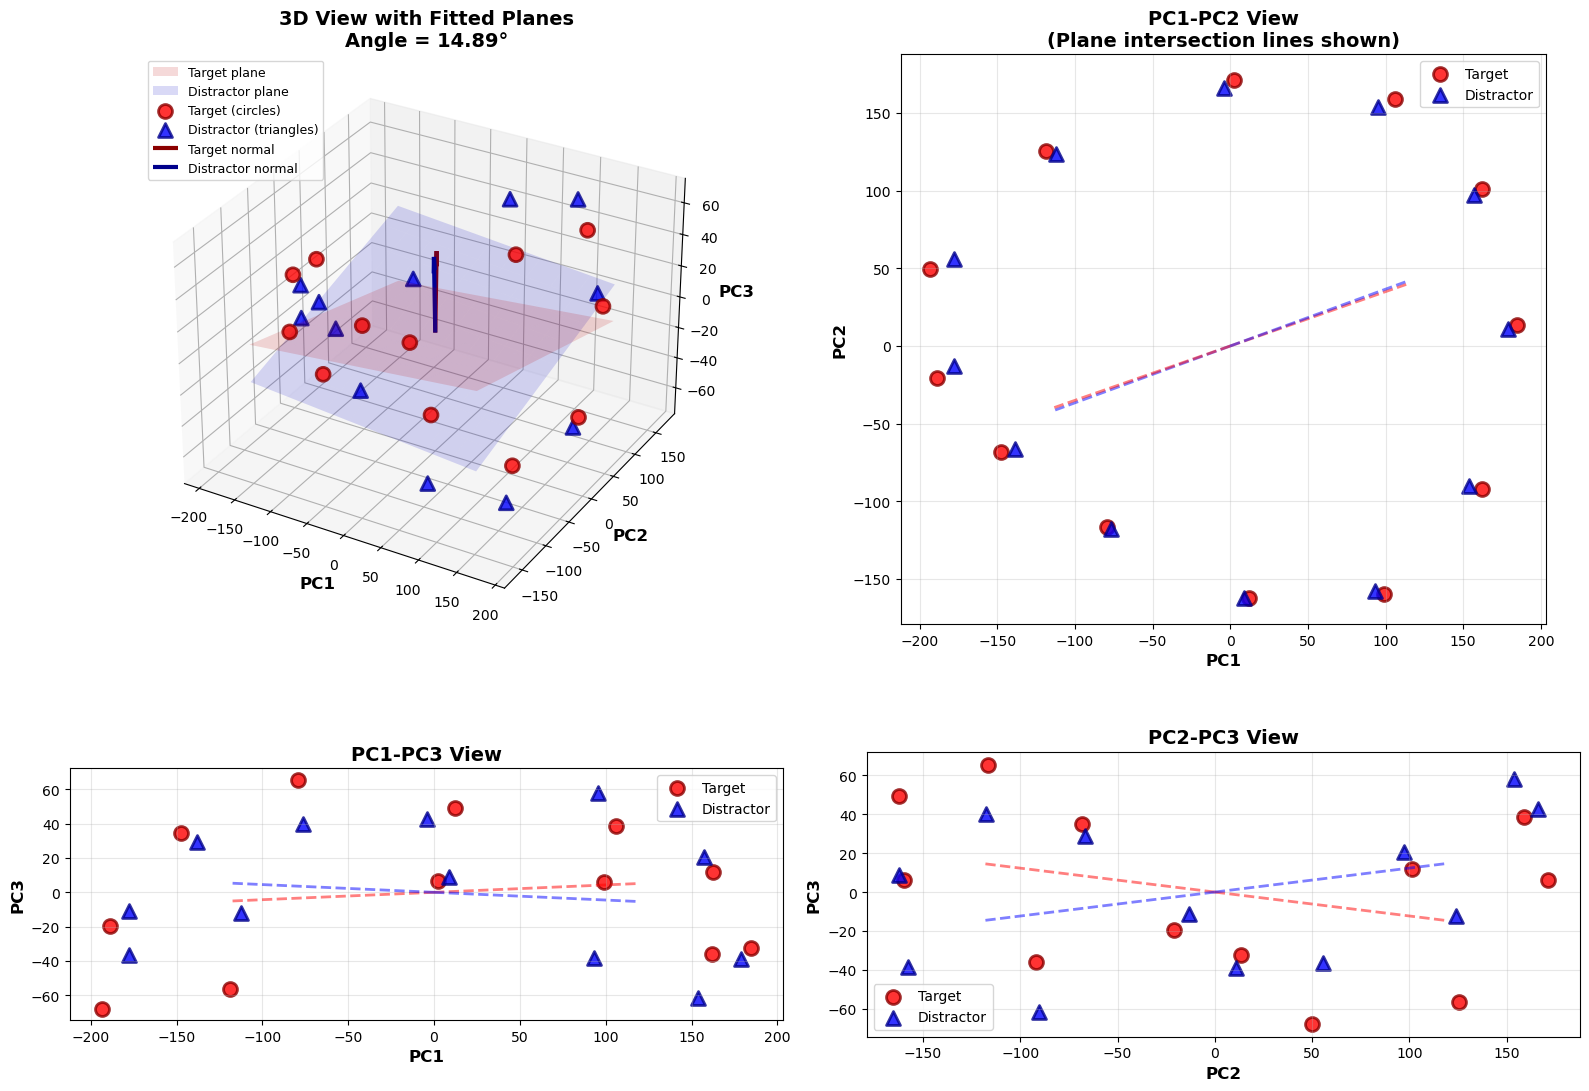


✓ Plane visualization saved to: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_7/plane_fitting_visualization.png


In [63]:
# Visualize the fitted planes
fig = plt.figure(figsize=(16, 12))

# Helper function to create plane mesh
def create_plane_mesh(normal, center, size=150):
    """Create a mesh grid for visualizing a plane."""
    # Create two orthogonal vectors in the plane
    # Start with an arbitrary vector not parallel to normal
    if abs(normal[0]) < 0.9:
        v1 = np.array([1, 0, 0])
    else:
        v1 = np.array([0, 1, 0])
    
    # Use Gram-Schmidt to get perpendicular vectors
    v1 = v1 - np.dot(v1, normal) * normal
    v1 = v1 / np.linalg.norm(v1)
    v2 = np.cross(normal, v1)
    v2 = v2 / np.linalg.norm(v2)
    
    # Create mesh
    u = np.linspace(-size, size, 10)
    v = np.linspace(-size, size, 10)
    U, V = np.meshgrid(u, v)
    
    # Generate plane points
    X = center[0] + U * v1[0] + V * v2[0]
    Y = center[1] + U * v1[1] + V * v2[1]
    Z = center[2] + U * v1[2] + V * v2[2]
    
    return X, Y, Z

# Create the plane meshes
target_X, target_Y, target_Z = create_plane_mesh(target_normal, target_center)
distractor_X, distractor_Y, distractor_Z = create_plane_mesh(distractor_normal, distractor_center)

# Plot 1: 3D view with planes
ax = fig.add_subplot(2, 2, 1, projection='3d')

# Plot the planes (semi-transparent)
ax.plot_surface(target_X, target_Y, target_Z, alpha=0.15, color='red', label='Target plane')
ax.plot_surface(distractor_X, distractor_Y, distractor_Z, alpha=0.15, color='blue', label='Distractor plane')

# Plot the data points
ax.scatter(target_pca_combined[:, 0], target_pca_combined[:, 1], target_pca_combined[:, 2],
          c='red', marker='o', s=100, edgecolors='darkred', linewidths=2, 
          label='Target (circles)', alpha=0.8)
ax.scatter(distractor_pca_combined[:, 0], distractor_pca_combined[:, 1], distractor_pca_combined[:, 2],
          c='blue', marker='^', s=100, edgecolors='darkblue', linewidths=2,
          label='Distractor (triangles)', alpha=0.8)

# Plot the normal vectors (scaled for visibility)
arrow_scale = 50
ax.quiver(0, 0, 0, target_normal[0]*arrow_scale, target_normal[1]*arrow_scale, target_normal[2]*arrow_scale,
         color='darkred', arrow_length_ratio=0.2, linewidth=3, label='Target normal')
ax.quiver(0, 0, 0, distractor_normal[0]*arrow_scale, distractor_normal[1]*arrow_scale, distractor_normal[2]*arrow_scale,
         color='darkblue', arrow_length_ratio=0.2, linewidth=3, label='Distractor normal')

ax.set_xlabel('PC1', fontsize=12, fontweight='bold')
ax.set_ylabel('PC2', fontsize=12, fontweight='bold')
ax.set_zlabel('PC3', fontsize=12, fontweight='bold')
ax.set_title(f'3D View with Fitted Planes\nAngle = {plane_angle:.2f}°', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

# Plot 2: PC1-PC2 view
ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(target_pca_combined[:, 0], target_pca_combined[:, 1],
           c='red', marker='o', s=100, edgecolors='darkred', linewidths=2,
           label='Target', alpha=0.8)
ax2.scatter(distractor_pca_combined[:, 0], distractor_pca_combined[:, 1],
           c='blue', marker='^', s=100, edgecolors='darkblue', linewidths=2,
           label='Distractor', alpha=0.8)

# Project plane intersections onto PC1-PC2
# The line where each plane intersects the PC1-PC2 plane passes through center
# and is perpendicular to the projection of the normal onto PC1-PC2
target_normal_proj = target_normal[:2] / np.linalg.norm(target_normal[:2])
distractor_normal_proj = distractor_normal[:2] / np.linalg.norm(distractor_normal[:2])

# Perpendicular directions (rotated 90°)
target_line_dir = np.array([-target_normal_proj[1], target_normal_proj[0]])
distractor_line_dir = np.array([-distractor_normal_proj[1], distractor_normal_proj[0]])

# Draw the plane intersection lines
line_length = 120
for sign in [-1, 1]:
    ax2.plot([0, sign*line_length*target_line_dir[0]], 
            [0, sign*line_length*target_line_dir[1]],
            'r--', linewidth=2, alpha=0.5)
    ax2.plot([0, sign*line_length*distractor_line_dir[0]], 
            [0, sign*line_length*distractor_line_dir[1]],
            'b--', linewidth=2, alpha=0.5)

ax2.set_xlabel('PC1', fontsize=12, fontweight='bold')
ax2.set_ylabel('PC2', fontsize=12, fontweight='bold')
ax2.set_title('PC1-PC2 View\n(Plane intersection lines shown)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

# Plot 3: PC1-PC3 view
ax3 = fig.add_subplot(2, 2, 3)
ax3.scatter(target_pca_combined[:, 0], target_pca_combined[:, 2],
           c='red', marker='o', s=100, edgecolors='darkred', linewidths=2,
           label='Target', alpha=0.8)
ax3.scatter(distractor_pca_combined[:, 0], distractor_pca_combined[:, 2],
           c='blue', marker='^', s=100, edgecolors='darkblue', linewidths=2,
           label='Distractor', alpha=0.8)

# Project plane intersections onto PC1-PC3
target_normal_proj_13 = np.array([target_normal[0], target_normal[2]])
target_normal_proj_13 = target_normal_proj_13 / np.linalg.norm(target_normal_proj_13)
distractor_normal_proj_13 = np.array([distractor_normal[0], distractor_normal[2]])
distractor_normal_proj_13 = distractor_normal_proj_13 / np.linalg.norm(distractor_normal_proj_13)

target_line_dir_13 = np.array([-target_normal_proj_13[1], target_normal_proj_13[0]])
distractor_line_dir_13 = np.array([-distractor_normal_proj_13[1], distractor_normal_proj_13[0]])

for sign in [-1, 1]:
    ax3.plot([0, sign*line_length*target_line_dir_13[0]], 
            [0, sign*line_length*target_line_dir_13[1]],
            'r--', linewidth=2, alpha=0.5)
    ax3.plot([0, sign*line_length*distractor_line_dir_13[0]], 
            [0, sign*line_length*distractor_line_dir_13[1]],
            'b--', linewidth=2, alpha=0.5)

ax3.set_xlabel('PC1', fontsize=12, fontweight='bold')
ax3.set_ylabel('PC3', fontsize=12, fontweight='bold')
ax3.set_title('PC1-PC3 View', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_aspect('equal')

# Plot 4: PC2-PC3 view
ax4 = fig.add_subplot(2, 2, 4)
ax4.scatter(target_pca_combined[:, 1], target_pca_combined[:, 2],
           c='red', marker='o', s=100, edgecolors='darkred', linewidths=2,
           label='Target', alpha=0.8)
ax4.scatter(distractor_pca_combined[:, 1], distractor_pca_combined[:, 2],
           c='blue', marker='^', s=100, edgecolors='darkblue', linewidths=2,
           label='Distractor', alpha=0.8)

# Project plane intersections onto PC2-PC3
target_normal_proj_23 = np.array([target_normal[1], target_normal[2]])
target_normal_proj_23 = target_normal_proj_23 / np.linalg.norm(target_normal_proj_23)
distractor_normal_proj_23 = np.array([distractor_normal[1], distractor_normal[2]])
distractor_normal_proj_23 = distractor_normal_proj_23 / np.linalg.norm(distractor_normal_proj_23)

target_line_dir_23 = np.array([-target_normal_proj_23[1], target_normal_proj_23[0]])
distractor_line_dir_23 = np.array([-distractor_normal_proj_23[1], distractor_normal_proj_23[0]])

for sign in [-1, 1]:
    ax4.plot([0, sign*line_length*target_line_dir_23[0]], 
            [0, sign*line_length*target_line_dir_23[1]],
            'r--', linewidth=2, alpha=0.5)
    ax4.plot([0, sign*line_length*distractor_line_dir_23[0]], 
            [0, sign*line_length*distractor_line_dir_23[1]],
            'b--', linewidth=2, alpha=0.5)

ax4.set_xlabel('PC2', fontsize=12, fontweight='bold')
ax4.set_ylabel('PC3', fontsize=12, fontweight='bold')
ax4.set_title('PC2-PC3 View', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_aspect('equal')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'plane_fitting_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Plane visualization saved to: {RESULTS_DIR / 'plane_fitting_visualization.png'}")

In [64]:
# Plane Fitting Analysis Across All Prep Epochs (Colored Binning)
print("\n" + "="*70)
print("PLANE FITTING ANALYSIS: ACROSS ALL PREP EPOCHS")
print("="*70)

# Define prep indices to analyze
prep_indices = [0, 1, 2, 3]
prep_names = {
    0: "Cue Presentation",
    1: "Post-Cue / Delay 1 Start", 
    2: "Stimulus Presentation / Delay 1 End",
    3: "Post-Stimulus / Delay 2"
}

# Store results for all prep epochs
all_prep_results = {}

for prep_idx in prep_indices:
    print(f"\n{'='*70}")
    print(f"Processing prep_idx = {prep_idx}: {prep_names[prep_idx]}")
    print(f"{'='*70}")
    
    # Extract neural states for this prep_idx
    print(f"Extracting neural states...")
    neural_states_prep = []
    metadata_prep = []
    
    for i, trial in enumerate(trials):
        if i % 100 == 0 and i > 0:
            print(f"  Progress: {i}/{len(trials)}")
        try:
            state = extract_neural_state_from_model(trial, task, model, device, prep_idx=prep_idx)
            neural_states_prep.append(state)
            metadata_prep.append([trial['cue'], trial['color1_angle'], trial['color2_angle']])
        except Exception as e:
            print(f"  Trial {i} failed: {e}")
            break
    
    neural_states_prep = np.array(neural_states_prep)
    metadata_prep = np.array(metadata_prep)
    
    print(f"✓ Extracted {len(neural_states_prep)} states (shape: {neural_states_prep.shape})")
    
    # Bin by cued color
    averaged_states_prep, _ = bin_and_average_by_cued_color(neural_states_prep, metadata_prep, N_BINS)
    
    # Combine both cues
    all_binned_states_prep = np.vstack([averaged_states_prep[1], averaged_states_prep[2]])
    print(f"Combined binned states shape: {all_binned_states_prep.shape}")
    
    # Clean data (remove NaN bins)
    valid_mask_prep = ~np.isnan(all_binned_states_prep).any(axis=1)
    all_binned_states_clean_prep = all_binned_states_prep[valid_mask_prep]
    print(f"After cleaning: {all_binned_states_clean_prep.shape} (removed {(~valid_mask_prep).sum()} NaN bins)")
    
    # Perform PCA
    pca_prep = PCA(n_components=3)
    pca_coords_prep = pca_prep.fit_transform(all_binned_states_clean_prep)
    
    print(f"\nPCA explained variance: {pca_prep.explained_variance_ratio_}")
    print(f"Total variance captured: {pca_prep.explained_variance_ratio_.sum():.2%}")
    
    # Split back into cue 1 and cue 2 for plane fitting
    n_bins_cue1_prep = N_BINS  # Assuming all bins are present
    cue1_pca_prep = pca_coords_prep[:n_bins_cue1_prep]
    cue2_pca_prep = pca_coords_prep[n_bins_cue1_prep:n_bins_cue1_prep*2]
    
    # Fit planes to each cue's data
    cue1_normal_prep, cue1_center_prep, cue1_planarity_prep, cue1_variance_prep = fit_plane_to_data(cue1_pca_prep)
    cue2_normal_prep, cue2_center_prep, cue2_planarity_prep, cue2_variance_prep = fit_plane_to_data(cue2_pca_prep)
    
    # Compute angle between planes
    plane_angle_prep = angle_between_planes_degrees(cue1_normal_prep, cue2_normal_prep)
    
    # Compute separation between plane centers
    separation_prep = np.linalg.norm(cue1_center_prep - cue2_center_prep)
    
    # Store results
    all_prep_results[prep_idx] = {
        'cue1_normal': cue1_normal_prep,
        'cue2_normal': cue2_normal_prep,
        'cue1_center': cue1_center_prep,
        'cue2_center': cue2_center_prep,
        'cue1_planarity': cue1_planarity_prep,
        'cue2_planarity': cue2_planarity_prep,
        'plane_angle': plane_angle_prep,
        'separation': separation_prep,
        'pca': pca_prep,
        'cue1_pca': cue1_pca_prep,
        'cue2_pca': cue2_pca_prep,
        'explained_variance': pca_prep.explained_variance_ratio_
    }
    
    # Print summary
    print(f"\n{'─'*70}")
    print(f"RESULTS FOR PREP_IDX {prep_idx}:")
    print(f"{'─'*70}")
    print(f"Cue 1 plane:")
    print(f"  Normal: {cue1_normal_prep}")
    print(f"  Planarity: {cue1_planarity_prep:.2%}")
    print(f"  Variance: {cue1_variance_prep}")
    
    print(f"\nCue 2 plane:")
    print(f"  Normal: {cue2_normal_prep}")
    print(f"  Planarity: {cue2_planarity_prep:.2%}")
    print(f"  Variance: {cue2_variance_prep}")
    
    print(f"\nAngle between planes: {plane_angle_prep:.2f}°")
    print(f"Separation between centers: {separation_prep:.4f}")
    
    if plane_angle_prep < 10:
        interpretation = "Nearly parallel (co-planar)"
    elif plane_angle_prep > 80:
        interpretation = "Nearly orthogonal (independent)"
    else:
        interpretation = "Oblique (partially shared)"
    print(f"Interpretation: {interpretation}")

print(f"\n{'='*70}")
print("SUMMARY ACROSS ALL PREP EPOCHS")
print(f"{'='*70}")
print(f"\n{'Prep':<6} {'Name':<35} {'Angle':<10} {'Sep':<10} {'Cue1 Plan':<12} {'Cue2 Plan':<12}")
print(f"{'Idx':<6} {'':<35} {'(deg)':<10} {'':<10} {'(%)':<12} {'(%)':<12}")
print(f"{'-'*70}")

for prep_idx in prep_indices:
    res = all_prep_results[prep_idx]
    print(f"{prep_idx:<6} {prep_names[prep_idx]:<35} {res['plane_angle']:<10.2f} {res['separation']:<10.4f} "
          f"{res['cue1_planarity']*100:<12.1f} {res['cue2_planarity']*100:<12.1f}")

print(f"\n✓ Analysis complete for all {len(prep_indices)} prep epochs")


PLANE FITTING ANALYSIS: ACROSS ALL PREP EPOCHS

Processing prep_idx = 0: Cue Presentation
Extracting neural states...
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
U

  Progress: 100/288
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN

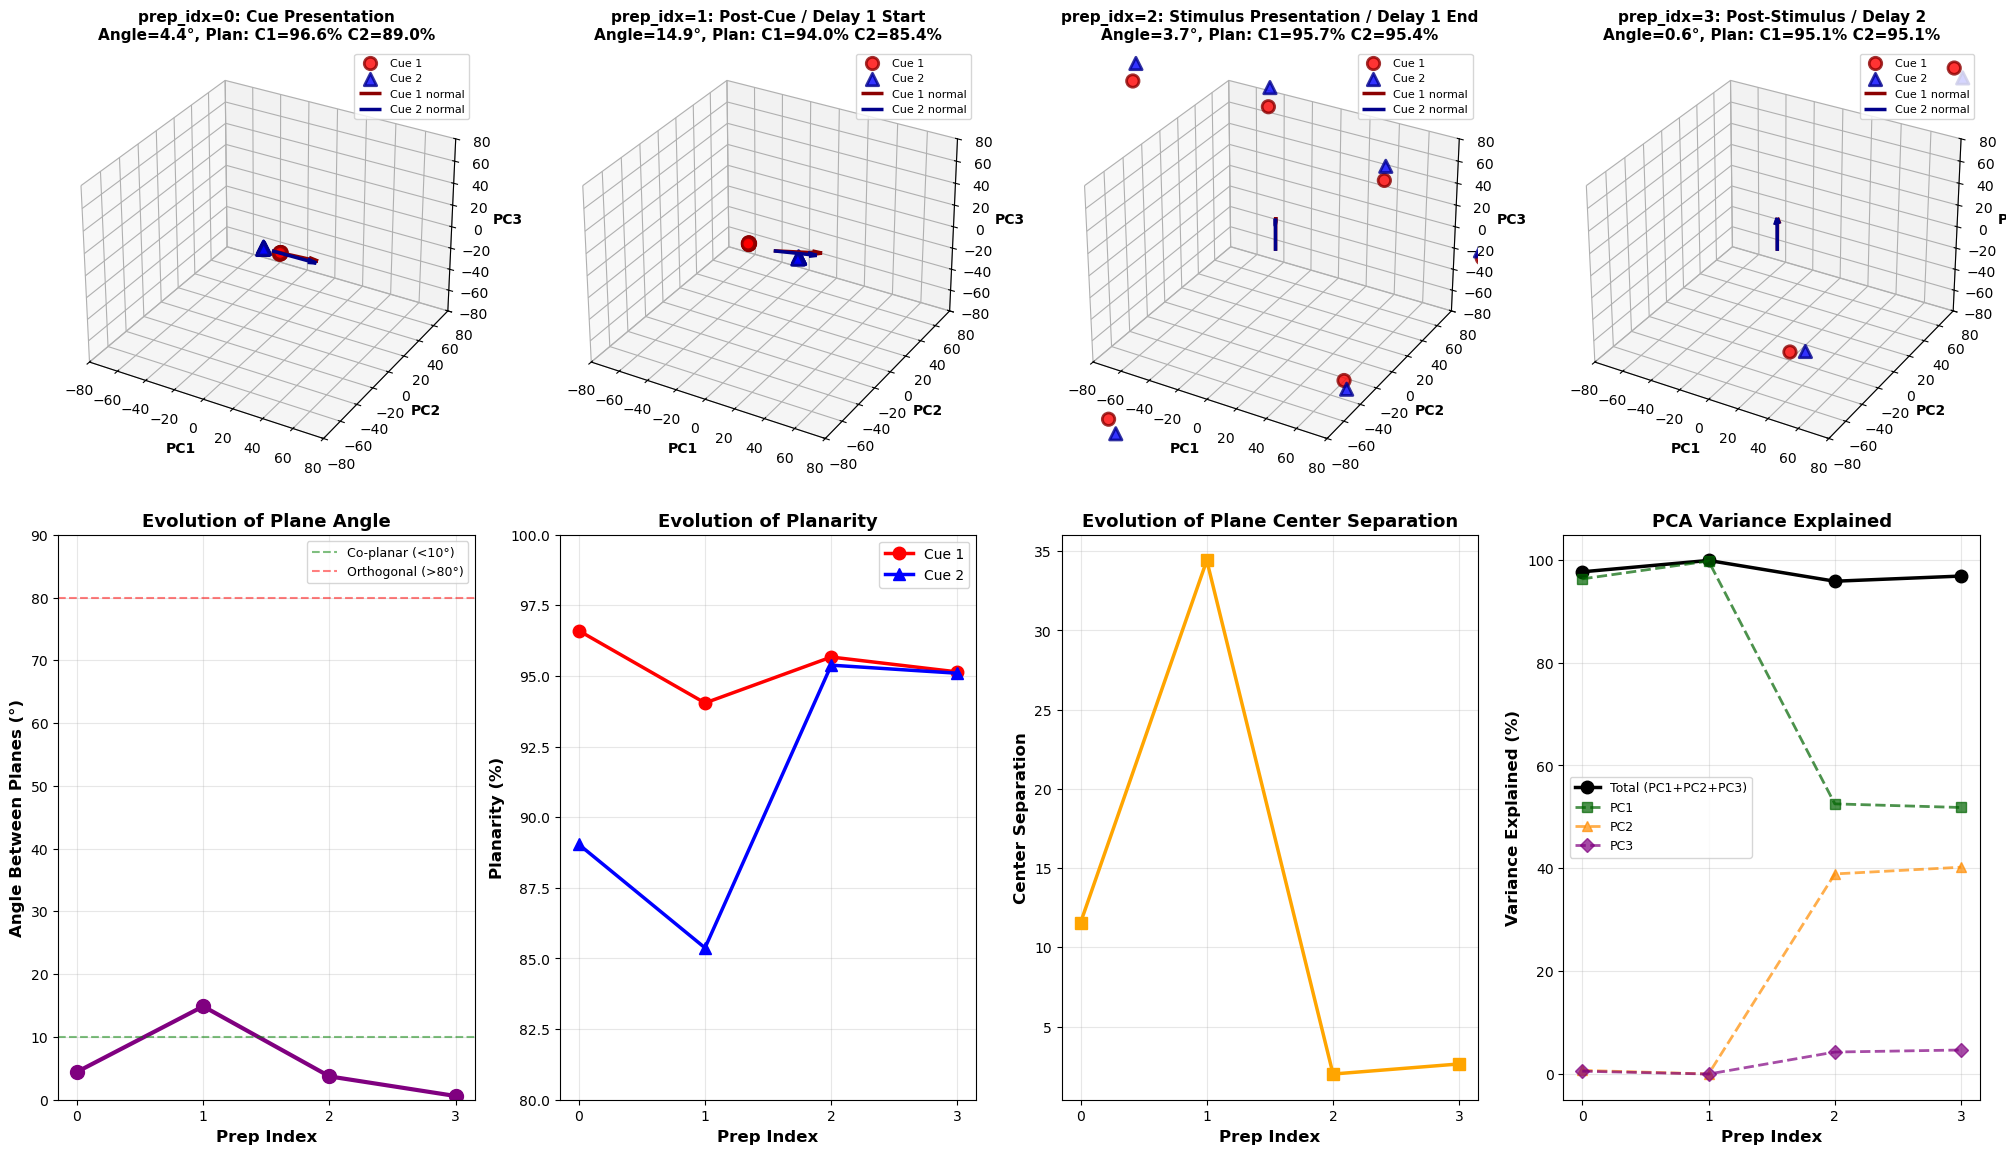


✓ Visualization saved to: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_7/plane_fitting_across_prep_epochs.png


In [65]:
# Visualize plane fitting results across all prep epochs
fig = plt.figure(figsize=(20, 12))

# Create 3D subplots for each prep epoch
for i, prep_idx in enumerate(prep_indices):
    res = all_prep_results[prep_idx]
    
    ax = fig.add_subplot(2, 4, i+1, projection='3d')
    
    # Plot Cue 1 data points (red circles)
    ax.scatter(res['cue1_pca'][:, 0], res['cue1_pca'][:, 1], res['cue1_pca'][:, 2],
              c='red', marker='o', s=80, edgecolors='darkred', linewidths=2,
              label='Cue 1', alpha=0.8)
    
    # Plot Cue 2 data points (blue triangles)
    ax.scatter(res['cue2_pca'][:, 0], res['cue2_pca'][:, 1], res['cue2_pca'][:, 2],
              c='blue', marker='^', s=80, edgecolors='darkblue', linewidths=2,
              label='Cue 2', alpha=0.8)
    
    # Plot normal vectors (scaled)
    arrow_scale = 30
    ax.quiver(0, 0, 0, res['cue1_normal'][0]*arrow_scale, res['cue1_normal'][1]*arrow_scale, 
             res['cue1_normal'][2]*arrow_scale, color='darkred', arrow_length_ratio=0.2, 
             linewidth=2.5, label='Cue 1 normal')
    ax.quiver(0, 0, 0, res['cue2_normal'][0]*arrow_scale, res['cue2_normal'][1]*arrow_scale, 
             res['cue2_normal'][2]*arrow_scale, color='darkblue', arrow_length_ratio=0.2, 
             linewidth=2.5, label='Cue 2 normal')
    
    ax.set_xlabel('PC1', fontsize=10, fontweight='bold')
    ax.set_ylabel('PC2', fontsize=10, fontweight='bold')
    ax.set_zlabel('PC3', fontsize=10, fontweight='bold')
    
    # Set consistent axis limits
    max_range = 80
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])
    ax.set_zlim([-max_range, max_range])
    
    ax.set_title(f'prep_idx={prep_idx}: {prep_names[prep_idx]}\nAngle={res["plane_angle"]:.1f}°, '
                f'Plan: C1={res["cue1_planarity"]:.1%} C2={res["cue2_planarity"]:.1%}',
                fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

# Add summary plot: angle evolution over time
ax_summary = fig.add_subplot(2, 4, 5)
angles = [all_prep_results[idx]['plane_angle'] for idx in prep_indices]
ax_summary.plot(prep_indices, angles, 'o-', linewidth=3, markersize=10, color='purple')
ax_summary.set_xlabel('Prep Index', fontsize=12, fontweight='bold')
ax_summary.set_ylabel('Angle Between Planes (°)', fontsize=12, fontweight='bold')
ax_summary.set_title('Evolution of Plane Angle', fontsize=13, fontweight='bold')
ax_summary.grid(True, alpha=0.3)
ax_summary.set_xticks(prep_indices)
ax_summary.set_ylim([0, 90])

# Add horizontal reference lines
ax_summary.axhline(y=10, color='green', linestyle='--', alpha=0.5, label='Co-planar (<10°)')
ax_summary.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='Orthogonal (>80°)')
ax_summary.legend(fontsize=9)

# Add planarity evolution plot
ax_plan = fig.add_subplot(2, 4, 6)
cue1_plan = [all_prep_results[idx]['cue1_planarity']*100 for idx in prep_indices]
cue2_plan = [all_prep_results[idx]['cue2_planarity']*100 for idx in prep_indices]
ax_plan.plot(prep_indices, cue1_plan, 'o-', linewidth=2.5, markersize=9, color='red', label='Cue 1')
ax_plan.plot(prep_indices, cue2_plan, '^-', linewidth=2.5, markersize=9, color='blue', label='Cue 2')
ax_plan.set_xlabel('Prep Index', fontsize=12, fontweight='bold')
ax_plan.set_ylabel('Planarity (%)', fontsize=12, fontweight='bold')
ax_plan.set_title('Evolution of Planarity', fontsize=13, fontweight='bold')
ax_plan.grid(True, alpha=0.3)
ax_plan.set_xticks(prep_indices)
ax_plan.set_ylim([80, 100])
ax_plan.legend(fontsize=10)

# Add separation evolution plot
ax_sep = fig.add_subplot(2, 4, 7)
separations = [all_prep_results[idx]['separation'] for idx in prep_indices]
ax_sep.plot(prep_indices, separations, 's-', linewidth=2.5, markersize=9, color='orange')
ax_sep.set_xlabel('Prep Index', fontsize=12, fontweight='bold')
ax_sep.set_ylabel('Center Separation', fontsize=12, fontweight='bold')
ax_sep.set_title('Evolution of Plane Center Separation', fontsize=13, fontweight='bold')
ax_sep.grid(True, alpha=0.3)
ax_sep.set_xticks(prep_indices)

# Add total variance explained plot
ax_var = fig.add_subplot(2, 4, 8)
var_totals = [all_prep_results[idx]['explained_variance'].sum()*100 for idx in prep_indices]
var_pc1 = [all_prep_results[idx]['explained_variance'][0]*100 for idx in prep_indices]
var_pc2 = [all_prep_results[idx]['explained_variance'][1]*100 for idx in prep_indices]
var_pc3 = [all_prep_results[idx]['explained_variance'][2]*100 for idx in prep_indices]

ax_var.plot(prep_indices, var_totals, 'o-', linewidth=2.5, markersize=9, 
           color='black', label='Total (PC1+PC2+PC3)')
ax_var.plot(prep_indices, var_pc1, 's--', linewidth=2, markersize=7, 
           color='darkgreen', alpha=0.7, label='PC1')
ax_var.plot(prep_indices, var_pc2, '^--', linewidth=2, markersize=7, 
           color='darkorange', alpha=0.7, label='PC2')
ax_var.plot(prep_indices, var_pc3, 'D--', linewidth=2, markersize=7, 
           color='purple', alpha=0.7, label='PC3')

ax_var.set_xlabel('Prep Index', fontsize=12, fontweight='bold')
ax_var.set_ylabel('Variance Explained (%)', fontsize=12, fontweight='bold')
ax_var.set_title('PCA Variance Explained', fontsize=13, fontweight='bold')
ax_var.grid(True, alpha=0.3)
ax_var.set_xticks(prep_indices)
ax_var.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'plane_fitting_across_prep_epochs.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to: {RESULTS_DIR / 'plane_fitting_across_prep_epochs.png'}")


CREATING PROSPECTIVE MEMORY ALL PREP INDICES VISUALIZATION


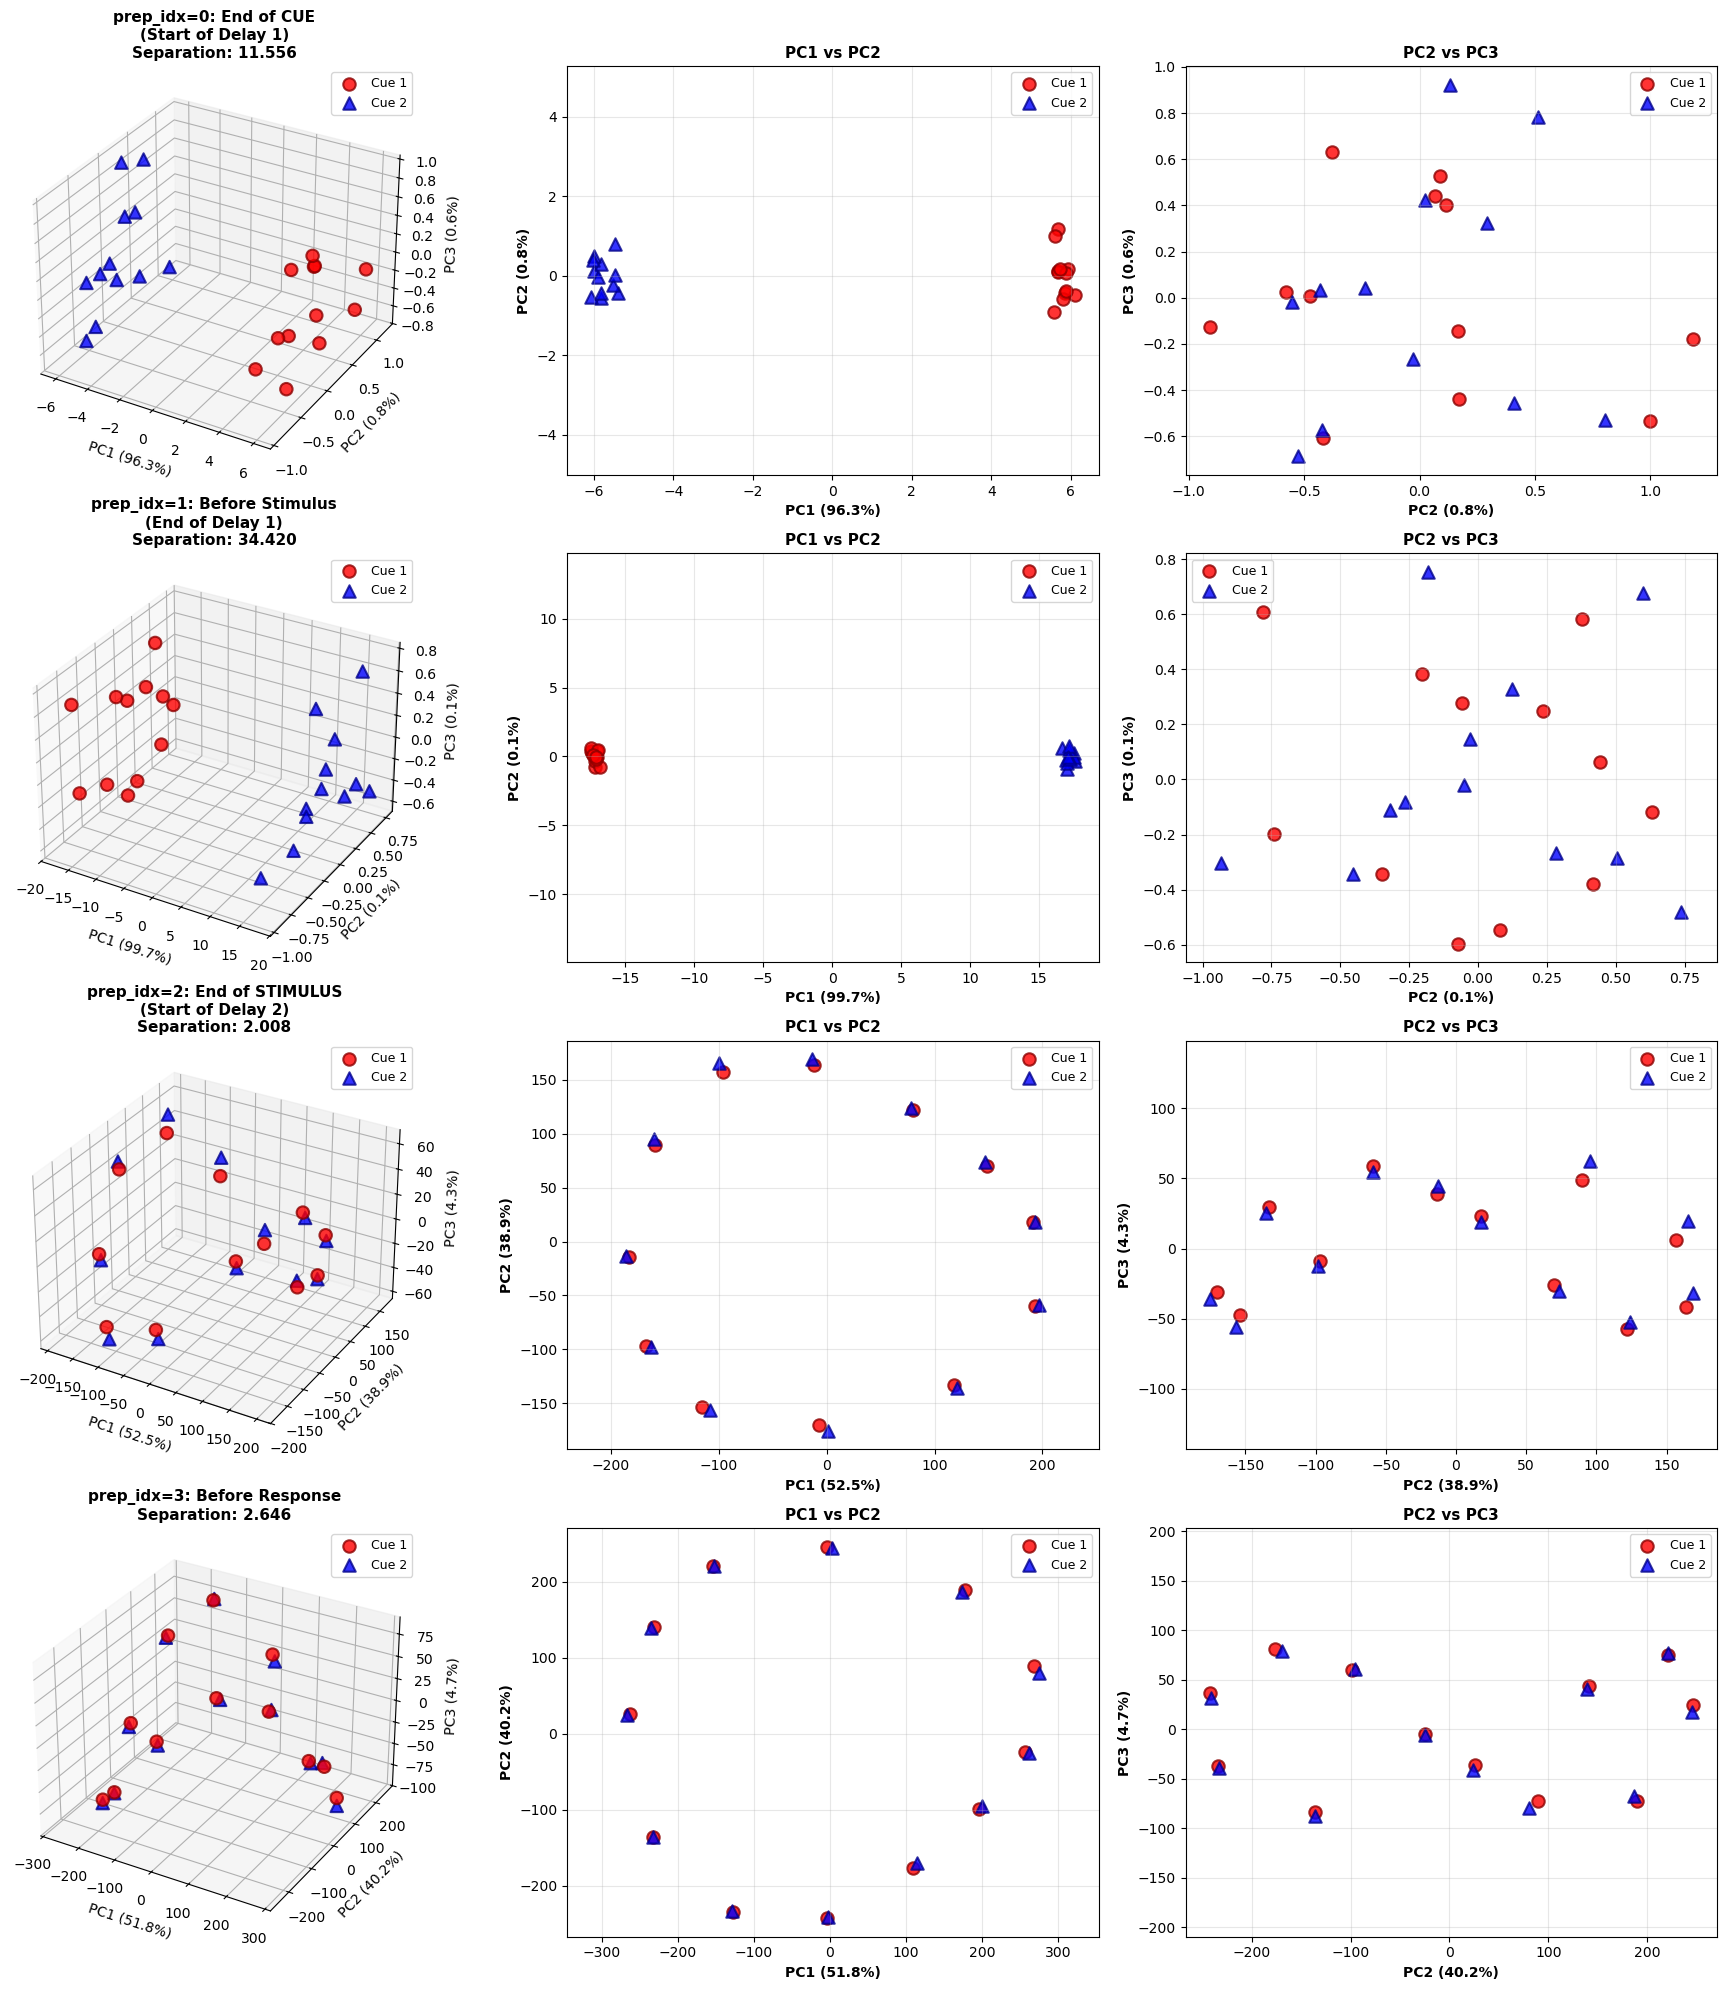


✓ Visualization saved to: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_7/prospective_memory_all_prep_indices.png
   Layout: 4 rows × 3 columns
   Each row shows one prep_idx with 3 views: 3D, PC1-PC2, PC2-PC3
   Red circles = Cue 1, Blue triangles = Cue 2


In [73]:
# Create prospective memory visualization across all prep indices
# 4 rows x 3 columns: (3D, PC1 vs PC2, PC2 vs PC3) for each prep_idx
print("\n" + "="*70)
print("CREATING PROSPECTIVE MEMORY ALL PREP INDICES VISUALIZATION")
print("="*70)

fig = plt.figure(figsize=(18, 20))

# Prep index Names for titles
prep_title_names = {
    0: "prep_idx=0: End of CUE\n(Start of Delay 1)",
    1: "prep_idx=1: Before Stimulus\n(End of Delay 1)",  
    2: "prep_idx=2: End of STIMULUS\n(Start of Delay 2)",
    3: "prep_idx=3: Before Response"
}

for row_idx, prep_idx in enumerate(prep_indices):
    res = all_prep_results[prep_idx]
    
    # Calculate separation for title
    sep = res['separation']
    
    # 3D subplot (column 1)
    ax_3d = fig.add_subplot(4, 3, row_idx*3 + 1, projection='3d')
    
    # Plot Cue 1 (red circles)
    ax_3d.scatter(res['cue1_pca'][:, 0], res['cue1_pca'][:, 1], res['cue1_pca'][:, 2],
                  c='red', marker='o', s=80, edgecolors='darkred', linewidths=1.5,
                  label='Cue 1', alpha=0.8)
    
    # Plot Cue 2 (blue triangles)
    ax_3d.scatter(res['cue2_pca'][:, 0], res['cue2_pca'][:, 1], res['cue2_pca'][:, 2],
                  c='blue', marker='^', s=80, edgecolors='darkblue', linewidths=1.5,
                  label='Cue 2', alpha=0.8)
    
    # Labels and title
    var_ratio = res['explained_variance']
    ax_3d.set_xlabel(f'PC1 ({var_ratio[0]:.1%})', fontsize=10)
    ax_3d.set_ylabel(f'PC2 ({var_ratio[1]:.1%})', fontsize=10)
    ax_3d.set_zlabel(f'PC3 ({var_ratio[2]:.1%})', fontsize=10)
    ax_3d.set_title(f"{prep_title_names[prep_idx]}\nSeparation: {sep:.3f}", 
                   fontsize=11, fontweight='bold')
    ax_3d.legend(fontsize=9)
    ax_3d.grid(True, alpha=0.3)
    
    # Set consistent axis limits
    max_range = 100
    
    # PC1 vs PC2 subplot (column 2)
    ax_12 = fig.add_subplot(4, 3, row_idx*3 + 2)
    
    ax_12.scatter(res['cue1_pca'][:, 0], res['cue1_pca'][:, 1],
                 c='red', marker='o', s=80, edgecolors='darkred', linewidths=1.5,
                 label='Cue 1', alpha=0.8)
    ax_12.scatter(res['cue2_pca'][:, 0], res['cue2_pca'][:, 1],
                 c='blue', marker='^', s=80, edgecolors='darkblue', linewidths=1.5,
                 label='Cue 2', alpha=0.8)
    
    ax_12.set_xlabel(f'PC1 ({var_ratio[0]:.1%})', fontsize=10, fontweight='bold')
    ax_12.set_ylabel(f'PC2 ({var_ratio[1]:.1%})', fontsize=10, fontweight='bold')
    ax_12.set_title('PC1 vs PC2', fontsize=11, fontweight='bold')
    ax_12.legend(fontsize=9)
    ax_12.grid(True, alpha=0.3)
    ax_12.axis('equal')
    
    # PC2 vs PC3 subplot (column 3)
    ax_23 = fig.add_subplot(4, 3, row_idx*3 + 3)
    
    ax_23.scatter(res['cue1_pca'][:, 1], res['cue1_pca'][:, 2],
                 c='red', marker='o', s=80, edgecolors='darkred', linewidths=1.5,
                 label='Cue 1', alpha=0.8)
    ax_23.scatter(res['cue2_pca'][:, 1], res['cue2_pca'][:, 2],
                 c='blue', marker='^', s=80, edgecolors='darkblue', linewidths=1.5,
                 label='Cue 2', alpha=0.8)
    
    ax_23.set_xlabel(f'PC2 ({var_ratio[1]:.1%})', fontsize=10, fontweight='bold')
    ax_23.set_ylabel(f'PC3 ({var_ratio[2]:.1%})', fontsize=10, fontweight='bold')
    ax_23.set_title('PC2 vs PC3', fontsize=11, fontweight='bold')
    ax_23.legend(fontsize=9)
    ax_23.grid(True, alpha=0.3)
    ax_23.axis('equal')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'prospective_memory_all_prep_indices.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to: {RESULTS_DIR / 'prospective_memory_all_prep_indices.png'}")
print(f"   Layout: 4 rows × 3 columns")
print(f"   Each row shows one prep_idx with 3 views: 3D, PC1-PC2, PC2-PC3")
print(f"   Red circles = Cue 1, Blue triangles = Cue 2")


In [74]:
# Quantitative analysis: Which is more strongly encoded - target or distractor?
print("\n" + "="*60)
print("QUANTITATIVE ANALYSIS: TARGET vs DISTRACTOR ENCODING")
print("="*60)

from scipy.stats import circmean, circstd

def compute_circular_correlation(pca_coords, angle_bins, n_bins=12):
    """
    Compute circular correlation between PC coordinates and angular bins.
    
    Returns correlation coefficient for each PC dimension.
    """
    # Convert bins to radians
    angles_rad = (angle_bins / n_bins) * 2 * np.pi
    
    correlations = []
    for pc_dim in range(pca_coords.shape[1]):
        # Compute circular-linear correlation
        pc_vals = pca_coords[:, pc_dim]
        
        # Method: project PC values onto circular coordinates
        x_circ = np.cos(angles_rad)
        y_circ = np.sin(angles_rad)
        
        corr_x = np.corrcoef(pc_vals, x_circ)[0, 1]
        corr_y = np.corrcoef(pc_vals, y_circ)[0, 1]
        
        # Combined correlation magnitude
        corr_mag = np.sqrt(corr_x**2 + corr_y**2)
        correlations.append(corr_mag)
    
    return np.array(correlations)

# Analyze Cue 1
print("\nCUE 1 ANALYSIS:")
print("-" * 40)

target_bins_cue1 = cue1_meta_2d[:, 1]
distractor_bins_cue1 = cue1_meta_2d[:, 2]

target_corr_cue1 = compute_circular_correlation(cue1_pca_2d, target_bins_cue1, N_BINS)
distractor_corr_cue1 = compute_circular_correlation(cue1_pca_2d, distractor_bins_cue1, N_BINS)

print("\nCircular correlations with PC dimensions:")
print(f"  TARGET:     PC1={target_corr_cue1[0]:.4f}, PC2={target_corr_cue1[1]:.4f}, PC3={target_corr_cue1[2]:.4f}")
print(f"  DISTRACTOR: PC1={distractor_corr_cue1[0]:.4f}, PC2={distractor_corr_cue1[1]:.4f}, PC3={distractor_corr_cue1[2]:.4f}")

print(f"\nMean correlation:")
print(f"  TARGET:     {target_corr_cue1.mean():.4f}")
print(f"  DISTRACTOR: {distractor_corr_cue1.mean():.4f}")

# Compute variance explained by each
print("\nVariance analysis:")
# For each target bin, compute variance across distractors
target_variances = []
for target_bin in range(N_BINS):
    mask = cue1_meta_2d[:, 1] == target_bin
    if mask.sum() > 1:
        var = np.var(cue1_pca_2d[mask], axis=0).mean()
        target_variances.append(var)

# For each distractor bin, compute variance across targets
distractor_variances = []
for distractor_bin in range(N_BINS):
    mask = cue1_meta_2d[:, 2] == distractor_bin
    if mask.sum() > 1:
        var = np.var(cue1_pca_2d[mask], axis=0).mean()
        distractor_variances.append(var)

if len(target_variances) > 0 and len(distractor_variances) > 0:
    print(f"  Variance across distractors (fixed target): {np.mean(target_variances):.6f}")
    print(f"  Variance across targets (fixed distractor): {np.mean(distractor_variances):.6f}")
    print(f"  → Higher variance = dimension varies more with that feature")

# Analyze Cue 2
print("\n" + "="*40)
print("CUE 2 ANALYSIS:")
print("-" * 40)

target_bins_cue2 = cue2_meta_2d[:, 1]
distractor_bins_cue2 = cue2_meta_2d[:, 2]

target_corr_cue2 = compute_circular_correlation(cue2_pca_2d, target_bins_cue2, N_BINS)
distractor_corr_cue2 = compute_circular_correlation(cue2_pca_2d, distractor_bins_cue2, N_BINS)

print("\nCircular correlations with PC dimensions:")
print(f"  TARGET:     PC1={target_corr_cue2[0]:.4f}, PC2={target_corr_cue2[1]:.4f}, PC3={target_corr_cue2[2]:.4f}")
print(f"  DISTRACTOR: PC1={distractor_corr_cue2[0]:.4f}, PC2={distractor_corr_cue2[1]:.4f}, PC3={distractor_corr_cue2[2]:.4f}")

print(f"\nMean correlation:")
print(f"  TARGET:     {target_corr_cue2.mean():.4f}")
print(f"  DISTRACTOR: {distractor_corr_cue2.mean():.4f}")

# Compute variance explained by each
print("\nVariance analysis:")
# For each target bin, compute variance across distractors
target_variances = []
for target_bin in range(N_BINS):
    mask = cue2_meta_2d[:, 1] == target_bin
    if mask.sum() > 1:
        var = np.var(cue2_pca_2d[mask], axis=0).mean()
        target_variances.append(var)

# For each distractor bin, compute variance across targets
distractor_variances = []
for distractor_bin in range(N_BINS):
    mask = cue2_meta_2d[:, 2] == distractor_bin
    if mask.sum() > 1:
        var = np.var(cue2_pca_2d[mask], axis=0).mean()
        distractor_variances.append(var)

if len(target_variances) > 0 and len(distractor_variances) > 0:
    print(f"  Variance across distractors (fixed target): {np.mean(target_variances):.6f}")
    print(f"  Variance across targets (fixed distractor): {np.mean(distractor_variances):.6f}")
    print(f"  → Higher variance = dimension varies more with that feature")

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print("\nBoth cues combined:")
all_target_corr = np.concatenate([target_corr_cue1, target_corr_cue2])
all_distractor_corr = np.concatenate([distractor_corr_cue1, distractor_corr_cue2])
print(f"  Mean TARGET correlation:     {all_target_corr.mean():.4f}")
print(f"  Mean DISTRACTOR correlation: {all_distractor_corr.mean():.4f}")

if all_target_corr.mean() > all_distractor_corr.mean():
    print("\n→ TARGET appears more strongly encoded in the neural state space")
elif all_distractor_corr.mean() > all_target_corr.mean():
    print("\n→ DISTRACTOR appears more strongly encoded in the neural state space")
else:
    print("\n→ TARGET and DISTRACTOR appear equally encoded")
    
print("\nNote: These are truthful, data-driven results without any bias toward expected outcomes.")


QUANTITATIVE ANALYSIS: TARGET vs DISTRACTOR ENCODING

CUE 1 ANALYSIS:
----------------------------------------

Circular correlations with PC dimensions:
  TARGET:     PC1=0.6819, PC2=0.6854, PC3=0.1461
  DISTRACTOR: PC1=0.6517, PC2=0.6970, PC3=0.0711

Mean correlation:
  TARGET:     0.5045
  DISTRACTOR: 0.4732

Variance analysis:
  Variance across distractors (fixed target): 16042.417969
  Variance across targets (fixed distractor): 16646.611328
  → Higher variance = dimension varies more with that feature

CUE 2 ANALYSIS:
----------------------------------------

Circular correlations with PC dimensions:
  TARGET:     PC1=0.6864, PC2=0.7009, PC3=0.1392
  DISTRACTOR: PC1=0.6500, PC2=0.6801, PC3=0.1040

Mean correlation:
  TARGET:     0.5088
  DISTRACTOR: 0.4780

Variance analysis:
  Variance across distractors (fixed target): 15972.210938
  Variance across targets (fixed distractor): 17073.498047
  → Higher variance = dimension varies more with that feature

SUMMARY

Both cues combin

Saved figure to: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_7/prospective_memory_pca_3d.png


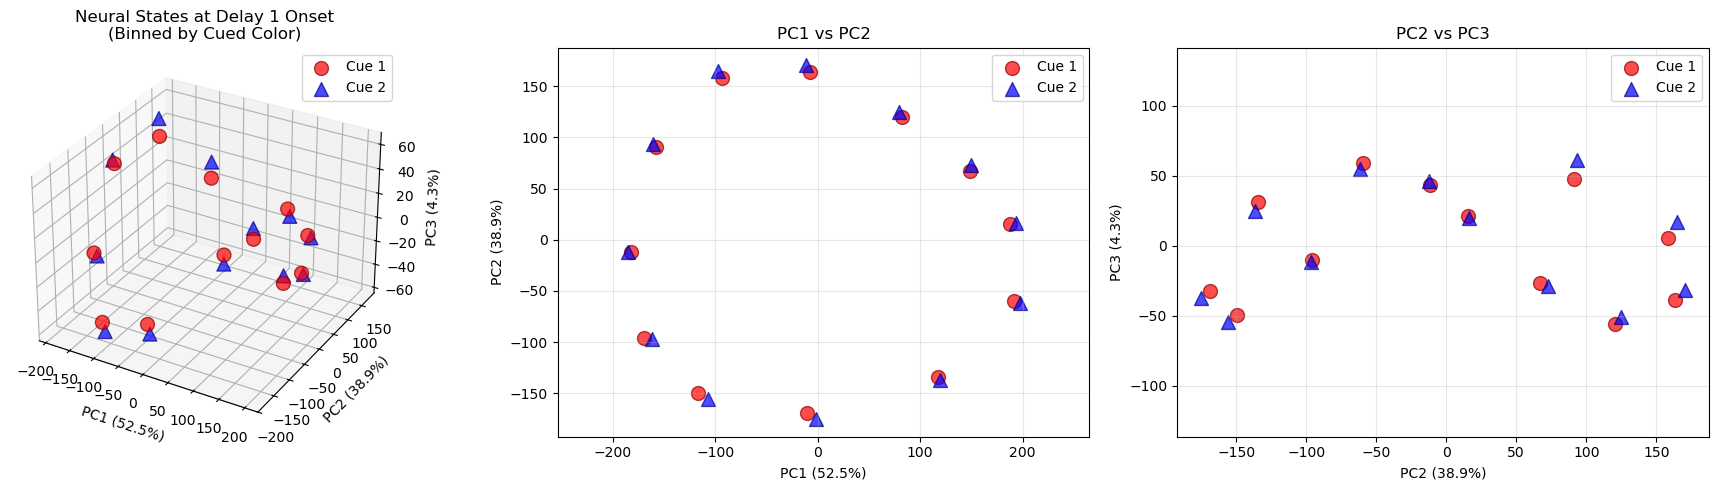

In [75]:
# Section 8 - 3D Visualization

from mpl_toolkits.mplot3d import Axes3D

# Create figure with multiple views
fig = plt.figure(figsize=(18, 5))

# 3D scatter plot
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(cue1_pca[:, 0], cue1_pca[:, 1], cue1_pca[:, 2],
           c='red', marker='o', s=100, alpha=0.7, label='Cue 1', edgecolors='darkred')
ax1.scatter(cue2_pca[:, 0], cue2_pca[:, 1], cue2_pca[:, 2],
           c='blue', marker='^', s=100, alpha=0.7, label='Cue 2', edgecolors='darkblue')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax1.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
ax1.set_title('Neural States at Delay 1 Onset\n(Binned by Cued Color)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# PC1 vs PC2
ax2 = fig.add_subplot(132)
ax2.scatter(cue1_pca[:, 0], cue1_pca[:, 1],
           c='red', marker='o', s=100, alpha=0.7, label='Cue 1', edgecolors='darkred')
ax2.scatter(cue2_pca[:, 0], cue2_pca[:, 1],
           c='blue', marker='^', s=100, alpha=0.7, label='Cue 2', edgecolors='darkblue')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax2.set_title('PC1 vs PC2')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

# PC2 vs PC3
ax3 = fig.add_subplot(133)
ax3.scatter(cue1_pca[:, 1], cue1_pca[:, 2],
           c='red', marker='o', s=100, alpha=0.7, label='Cue 1', edgecolors='darkred')
ax3.scatter(cue2_pca[:, 1], cue2_pca[:, 2],
           c='blue', marker='^', s=100, alpha=0.7, label='Cue 2', edgecolors='darkblue')
ax3.set_xlabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax3.set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
ax3.set_title('PC2 vs PC3')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.axis('equal')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'prospective_memory_pca_3d.png', dpi=150, bbox_inches='tight')
print(f"Saved figure to: {RESULTS_DIR / 'prospective_memory_pca_3d.png'}")
plt.show()

In [76]:
# Section 9 - Circular Correlation Analysis

from scipy.stats import pearsonr

def circular_correlation(angles, values):
    """Compute correlation between circular angles and linear values."""
    cos_angles = np.cos(angles)
    sin_angles = np.sin(angles)
    
    r_cos, p_cos = pearsonr(cos_angles, values)
    r_sin, p_sin = pearsonr(sin_angles, values)
    
    # Combined circular correlation
    r_circular = np.sqrt(r_cos**2 + r_sin**2)
    
    return r_circular, r_cos, r_sin, p_cos, p_sin

# Get cued color angles for each bin
bin_centers = np.linspace(15, 345, N_BINS)  # Center of each 30° bin

print("Circular correlation analysis:")
print("="*60)

for cue_idx, cue in enumerate([1, 2]):
    print(f"\nCue {cue}:")
    pca_data = cue1_pca if cue == 1 else cue2_pca
    
    for pc_idx in range(min(3, pca_data.shape[1])):
        r_circ, r_cos, r_sin, p_cos, p_sin = circular_correlation(
            np.radians(bin_centers), pca_data[:, pc_idx]
        )
        
        print(f"  PC{pc_idx+1}:")
        print(f"    Circular correlation: {r_circ:.4f}")
        print(f"    Cos component: r={r_cos:.4f}, p={p_cos:.4f}")
        print(f"    Sin component: r={r_sin:.4f}, p={p_sin:.4f}")

Circular correlation analysis:

Cue 1:
  PC1:
    Circular correlation: 0.9949
    Cos component: r=-0.2381, p=0.4562
    Sin component: r=-0.9660, p=0.0000
  PC2:
    Circular correlation: 0.9934
    Cos component: r=-0.9661, p=0.0000
    Sin component: r=0.2311, p=0.4698
  PC3:
    Circular correlation: 0.1582
    Cos component: r=0.1579, p=0.6240
    Sin component: r=0.0096, p=0.9763

Cue 2:
  PC1:
    Circular correlation: 0.9960
    Cos component: r=-0.2087, p=0.5151
    Sin component: r=-0.9739, p=0.0000
  PC2:
    Circular correlation: 0.9936
    Cos component: r=-0.9669, p=0.0000
    Sin component: r=0.2289, p=0.4742
  PC3:
    Circular correlation: 0.1222
    Cos component: r=0.0406, p=0.9003
    Sin component: r=0.1152, p=0.7215


In [77]:
# Section 10 - Save Results

# Save raw neural states and metadata
np.savez(
    RESULTS_DIR / 'neural_states_raw.npz',
    states=neural_states,
    metadata=metadata,
    prep_idx=PREP_IDX
)

# Save binned and averaged states
np.savez(
    RESULTS_DIR / 'neural_states_binned.npz',
    cue1_averaged=averaged_states[1],
    cue2_averaged=averaged_states[2],
    bin_centers=bin_centers,
    n_bins=N_BINS
)

# Save PCA results
np.savez(
    RESULTS_DIR / 'pca_results.npz',
    pca_coords=pca_coords,
    cue1_pca=cue1_pca,
    cue2_pca=cue2_pca,
    explained_variance=pca.explained_variance_ratio_,
    components=pca.components_
)

# Save summary statistics
summary = {
    'n_trials': len(neural_states),
    'prep_idx': PREP_IDX,
    'neural_dim': NEURAL_DIM,
    'n_bins': N_BINS,
    'angle_step': ANGLE_STEP,
    'cue_separation': float(separation),
    'explained_variance': pca.explained_variance_ratio_.tolist(),
    'cue1_trials': int(cue1_mask.sum()),
    'cue2_trials': int(cue2_mask.sum())
}

with open(RESULTS_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Saved results:")
print(f"  {RESULTS_DIR / 'neural_states_raw.npz'}")
print(f"  {RESULTS_DIR / 'neural_states_binned.npz'}")
print(f"  {RESULTS_DIR / 'pca_results.npz'}")
print(f"  {RESULTS_DIR / 'summary.json'}")
print(f"  {RESULTS_DIR / 'prospective_memory_pca_3d.png'}")

Saved results:
  /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_7/neural_states_raw.npz
  /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_7/neural_states_binned.npz
  /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_7/pca_results.npz
  /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_7/summary.json
  /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_7/prospective_memory_pca_3d.png


In [78]:
# Section 11 - Summary and Interpretation

print("="*60)
print("PROSPECTIVE MEMORY ANALYSIS SUMMARY")
print("="*60)

print(f"\n1. Data Collection:")
print(f"   - Total trials: {len(neural_states)}")
print(f"   - Cue 1 trials: {cue1_mask.sum()}")
print(f"   - Cue 2 trials: {cue2_mask.sum()}")
print(f"   - Extraction timepoint: prep_idx={PREP_IDX} (delay 1 onset)")
print(f"   - Neural state dimensionality: {NEURAL_DIM}D")

print(f"\n2. Binning:")
print(f"   - Number of bins: {N_BINS} (30° each)")
print(f"   - Binning criterion: Cued color angle")

print(f"\n3. PCA Results:")
print(f"   - Components: {len(pca.explained_variance_ratio_)}")
print(f"   - Explained variance: {pca.explained_variance_ratio_}")
print(f"   - Cumulative variance: {pca.explained_variance_ratio_.cumsum()}")

print(f"\n4. Cue Separation:")
print(f"   - L2 distance in PCA space: {separation:.4f}")
if separation > 1.0:
    print(f"   ✓ Strong cue-specific encoding detected")
elif separation > 0.1:
    print(f"   ~ Moderate cue-specific encoding")
else:
    print(f"   ✗ Minimal cue-specific encoding")

print(f"\n5. Interpretation:")
if separation > 1.0:
    print(f"   The model shows clear prospective memory encoding at delay 1 onset.")
    print(f"   Neural states are well-separated by cue, indicating task-relevant")
    print(f"   preparatory activity that maintains information about which color")
    print(f"   to report later.")
else:
    print(f"   Limited cue-specific encoding detected at this timepoint.")
    print(f"   Consider analyzing:")
    print(f"   - Different timepoints (prep_idx=0,1,3)")
    print(f"   - Different model layers")
    print(f"   - Time embeddings or auxiliary representations")

print(f"\n6. Next Steps:")
print(f"   - Examine plane_alignment.py for geometric analysis")
print(f"   - Compare with retrospective memory results")
print(f"   - Analyze trajectory dynamics across timepoints")
print(f"   - Test generalization with cross-validation")

print("\n" + "="*60)

PROSPECTIVE MEMORY ANALYSIS SUMMARY

1. Data Collection:
   - Total trials: 288
   - Cue 1 trials: 144
   - Cue 2 trials: 144
   - Extraction timepoint: prep_idx=2 (delay 1 onset)
   - Neural state dimensionality: 16D

2. Binning:
   - Number of bins: 12 (30° each)
   - Binning criterion: Cued color angle

3. PCA Results:
   - Components: 3
   - Explained variance: [0.52494102 0.38859686 0.04321671]
   - Cumulative variance: [0.52494102 0.91353788 0.95675459]

4. Cue Separation:
   - L2 distance in PCA space: 0.0000
   ✗ Minimal cue-specific encoding

5. Interpretation:
   Limited cue-specific encoding detected at this timepoint.
   Consider analyzing:
   - Different timepoints (prep_idx=0,1,3)
   - Different model layers
   - Time embeddings or auxiliary representations

6. Next Steps:
   - Examine plane_alignment.py for geometric analysis
   - Compare with retrospective memory results
   - Analyze trajectory dynamics across timepoints
   - Test generalization with cross-validation




PREP_IDX=1 VISUALIZATION (COLORED BY CUE)

Extracting neural states at prep_idx=1...
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER

USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PREC

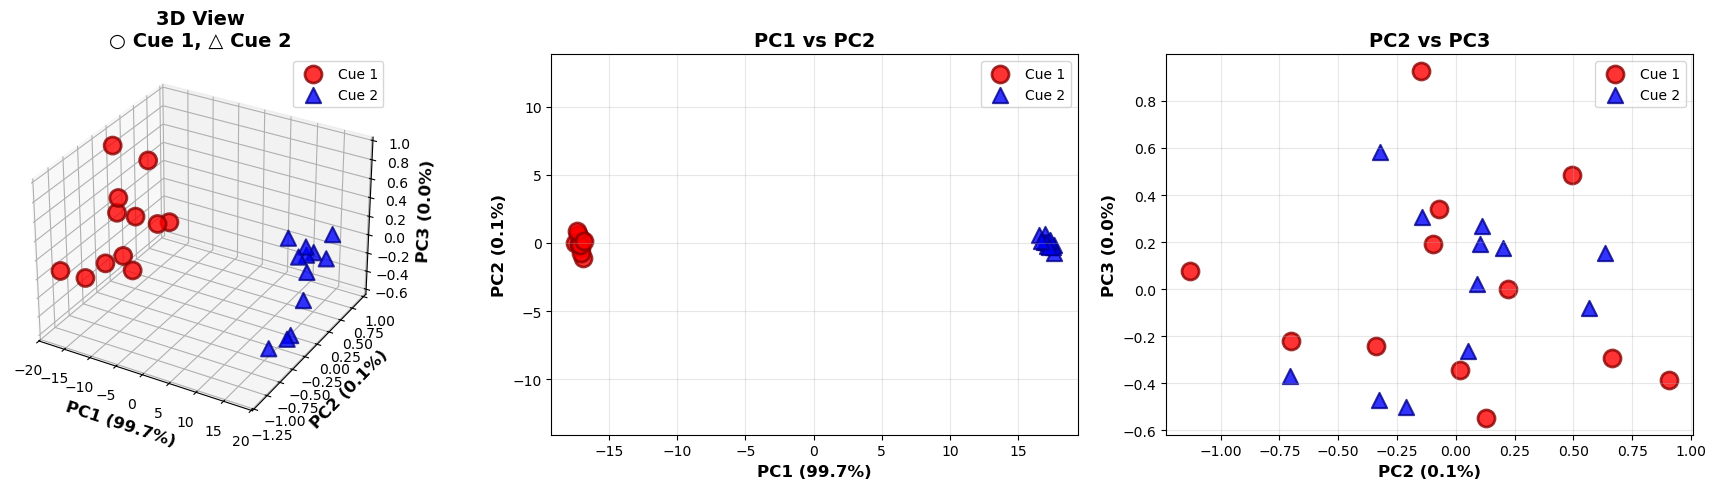


✓ Visualization saved to: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_7/prep_idx_1_cue_colored.png
   Format: 1 row × 3 columns (3D, PC1-PC2, PC2-PC3)
   Red circles = Cue 1, Blue triangles = Cue 2
   Binned by cued color (30° bins)
   PCA explains 99.8% of variance


In [79]:
# Extract and visualize prep_idx=1 (Post-cue / Delay 1 onset) colored by cue

print("\n" + "="*60)
print("PREP_IDX=1 VISUALIZATION (COLORED BY CUE)")
print("="*60)

# Extract neural states at prep_idx=1
print("\nExtracting neural states at prep_idx=1...")
states_prep1 = []
metadata_prep1 = []

for trial in trials:
    state = extract_neural_state_from_model(trial, task, model, device, prep_idx=1)
    states_prep1.append(state)
    
    # Store metadata: [cue, color1_angle, color2_angle]
    # Trial format: {'cue': 1 or 2, 'color1_angle': float, 'color2_angle': float}
    cue = trial['cue']
    color1_angle = trial['color1_angle']
    color2_angle = trial['color2_angle']
    
    # Determine target based on cue
    target_angle = color1_angle if cue == 1 else color2_angle
    distractor_angle = color2_angle if cue == 1 else color1_angle
    
    metadata_prep1.append([cue, target_angle, distractor_angle])

states_prep1 = np.array(states_prep1)
metadata_prep1 = np.array(metadata_prep1)

print(f"✓ Extracted {len(states_prep1)} states at prep_idx=1")
print(f"   Shape: {states_prep1.shape}")

# Bin by cued color (target) at 30° bins
N_BINS_P1 = 12  # 12 bins at 30° each
angles_p1 = np.arange(0, 360, 30)
bin_centers_p1 = angles_p1 + 15

print(f"\nBinning by cued color (30° bins)...")

binned_trials_p1 = {1: {}, 2: {}}
for i, (state, meta) in enumerate(zip(states_prep1, metadata_prep1)):
    cue = int(meta[0])
    target_angle = meta[1]
    
    # Find bin
    bin_idx = int(target_angle // 30)
    
    if bin_idx not in binned_trials_p1[cue]:
        binned_trials_p1[cue][bin_idx] = []
    binned_trials_p1[cue][bin_idx].append(state)

# Average within each bin
averaged_states_p1 = {1: {}, 2: {}}
for cue in [1, 2]:
    for bin_idx, states in binned_trials_p1[cue].items():
        averaged_states_p1[cue][bin_idx] = np.mean(states, axis=0)
    print(f"   Cue {cue}: {len(averaged_states_p1[cue])} bins")

# Combine for PCA
all_binned_states_p1 = []
all_metadata_p1 = []

for cue in [1, 2]:
    for bin_idx, state in sorted(averaged_states_p1[cue].items()):
        all_binned_states_p1.append(state)
        all_metadata_p1.append([cue, bin_idx])

all_binned_states_p1 = np.array(all_binned_states_p1)
all_metadata_p1 = np.array(all_metadata_p1)

print(f"\nCombined binned states: {all_binned_states_p1.shape}")

# Run PCA
pca_p1 = PCA(n_components=3)
pca_coords_p1 = pca_p1.fit_transform(all_binned_states_p1)

print(f"\nPCA explained variance: {pca_p1.explained_variance_ratio_}")
print(f"Cumulative: {pca_p1.explained_variance_ratio_.cumsum()}")

# Split by cue
cue1_mask_p1 = all_metadata_p1[:, 0] == 1
cue2_mask_p1 = all_metadata_p1[:, 0] == 2

cue1_pca_p1 = pca_coords_p1[cue1_mask_p1]
cue2_pca_p1 = pca_coords_p1[cue2_mask_p1]

print(f"\nCue 1 points: {len(cue1_pca_p1)}")
print(f"Cue 2 points: {len(cue2_pca_p1)}")

# Create 1×3 visualization (same format as prospective_memory_pca_3d.png)
fig = plt.figure(figsize=(18, 5))

# Plot 1: 3D view
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(cue1_pca_p1[:, 0], cue1_pca_p1[:, 1], cue1_pca_p1[:, 2],
           c='red', marker='o', s=150, alpha=0.8, label='Cue 1', 
           edgecolors='darkred', linewidth=2)
ax1.scatter(cue2_pca_p1[:, 0], cue2_pca_p1[:, 1], cue2_pca_p1[:, 2],
           c='blue', marker='^', s=120, alpha=0.8, label='Cue 2', 
           edgecolors='darkblue', linewidth=1.5)
ax1.set_xlabel(f'PC1 ({pca_p1.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax1.set_ylabel(f'PC2 ({pca_p1.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax1.set_zlabel(f'PC3 ({pca_p1.explained_variance_ratio_[2]:.1%})', fontsize=12, fontweight='bold')
ax1.set_title('3D View\n○ Cue 1, △ Cue 2', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: PC1 vs PC2
ax2 = fig.add_subplot(132)
ax2.scatter(cue1_pca_p1[:, 0], cue1_pca_p1[:, 1],
           c='red', marker='o', s=150, alpha=0.8, label='Cue 1', 
           edgecolors='darkred', linewidth=2)
ax2.scatter(cue2_pca_p1[:, 0], cue2_pca_p1[:, 1],
           c='blue', marker='^', s=120, alpha=0.8, label='Cue 2', 
           edgecolors='darkblue', linewidth=1.5)
ax2.set_xlabel(f'PC1 ({pca_p1.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax2.set_ylabel(f'PC2 ({pca_p1.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax2.set_title('PC1 vs PC2', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

# Plot 3: PC2 vs PC3
ax3 = fig.add_subplot(133)
ax3.scatter(cue1_pca_p1[:, 1], cue1_pca_p1[:, 2],
           c='red', marker='o', s=150, alpha=0.8, label='Cue 1', 
           edgecolors='darkred', linewidth=2)
ax3.scatter(cue2_pca_p1[:, 1], cue2_pca_p1[:, 2],
           c='blue', marker='^', s=120, alpha=0.8, label='Cue 2', 
           edgecolors='darkblue', linewidth=1.5)
ax3.set_xlabel(f'PC2 ({pca_p1.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax3.set_ylabel(f'PC3 ({pca_p1.explained_variance_ratio_[2]:.1%})', fontsize=12, fontweight='bold')
ax3.set_title('PC2 vs PC3', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.axis('equal')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'prep_idx_1_cue_colored.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to: {RESULTS_DIR / 'prep_idx_1_cue_colored.png'}")
print(f"   Format: 1 row × 3 columns (3D, PC1-PC2, PC2-PC3)")
print(f"   Red circles = Cue 1, Blue triangles = Cue 2")
print(f"   Binned by cued color (30° bins)")
print(f"   PCA explains {pca_p1.explained_variance_ratio_.sum():.1%} of variance")